# Conda Environment: 03_Beta-diversity

---

# Library Imports

In [1]:
# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# import OS for shell functionality
import os

# regular expressions
import re

# for python data manipulation and plotting
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# for running R through Python
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri

# Activate the pandas conversion to R dataframes
pandas2ri.activate()

# Load the rpy2 extension
%load_ext rpy2.ipython

# import R libraries
importr('vegan')
importr('dplyr')
importr('ape');

---

# Create Output Directories

In [2]:
# Create output directories for
!mkdir -p ../Datasets/Diversity/Beta
!mkdir -p ../Figures/Diversity/Beta

---

# Import Sample Metadata

In [3]:
sample_data = pd.read_csv("../Datasets/sample-data.csv")

---

# Ordination of 16S Communities

## Define function to perform PCoA by rarefaction using Bray-Curtis index and 100 subsamplings

In [4]:
def pcoa(file, output):
    sample_name = file.split("/")[-1].split(".")[0]
    output_path = output
    ro.r(f'''
    # Read in sequence table
    data = read.csv('{file}',sep = ',')
    # Set index to samples
    rownames(data) = data$ASV_ID
    data$ASV_ID = NULL
    data = t(data)
    
    # Calculate size to subset to
    size = min(rowSums(data))
    
    # Calculate Bray-Curtis Dissimilarity between samples
    community_distances = avgdist(x= data, sample= size, dmethod= 'bray')
    
    # Perform PCoA
    community_pcoa = pcoa(community_distances, correction= 'cailliez')

    # Get relative eigenvalues and add to column names
    eigenvalues = community_pcoa$values$Eigenvalues        # NOTE: this assumes no negative Eigenvalues, 
    eigenvalues = eigenvalues / sum(eigenvalues)           #       which is the case for all iterations here
    output_df = as.data.frame(community_pcoa$vectors)
    output_df = data.frame(output_df)
    column_names = paste0(colnames(output_df),' (',round(eigenvalues,2),')')
    colnames(output_df) = column_names
    
    # Export file
    write.csv(output_df,'{output_path}/{sample_name}_pcoa.csv')
    ''')
    print(f"PCoA peformed for '{sample_name}'. Output written to '{output_path}/{sample_name}_pcoa.csv'")
    

## Run PCoA using Bray-Curtis and rarefaction for all sample subsets

In [5]:
subsets = ['StageOneActive', 'StageTwoActive', 'StageOneResidentWeekEight', 'StageTwoResidentWeekEight',
           'StageTwoResidentWeekSix', 'StageTwoResidentWeekFour', 'StageTwoResidentWeekTwo']

for subset in subsets:
    file_name = f"../Datasets/SequenceTables/{subset}.csv"
    output = "../Datasets/Diversity/Beta"
    pcoa(file_name, output)

print("Done.")

PCoA peformed for 'StageOneActive'. Output written to '../Datasets/Diversity/Beta/StageOneActive_pcoa.csv'
PCoA peformed for 'StageTwoActive'. Output written to '../Datasets/Diversity/Beta/StageTwoActive_pcoa.csv'
PCoA peformed for 'StageOneResidentWeekEight'. Output written to '../Datasets/Diversity/Beta/StageOneResidentWeekEight_pcoa.csv'
PCoA peformed for 'StageTwoResidentWeekEight'. Output written to '../Datasets/Diversity/Beta/StageTwoResidentWeekEight_pcoa.csv'
PCoA peformed for 'StageTwoResidentWeekSix'. Output written to '../Datasets/Diversity/Beta/StageTwoResidentWeekSix_pcoa.csv'
PCoA peformed for 'StageTwoResidentWeekFour'. Output written to '../Datasets/Diversity/Beta/StageTwoResidentWeekFour_pcoa.csv'
PCoA peformed for 'StageTwoResidentWeekTwo'. Output written to '../Datasets/Diversity/Beta/StageTwoResidentWeekTwo_pcoa.csv'
Done.


---

# Plotting PCoA results

## Import PCoA data

In [4]:
# Import data for:

input_path = "../Datasets/Diversity/Beta"

## Sample metadata
sample_data = pd.read_csv("../Datasets/sample-data.csv")

## Stage 1 active data (week 8)
s1_active_pcoa = pd.read_csv(f"{input_path}/StageOneActive_pcoa.csv")
s1_active_pcoa.rename(columns= {"Unnamed: 0": "Sample"}, inplace= True)
s1_active_pcoa = pd.merge(left= s1_active_pcoa, right= sample_data[['Temperature','Sample']], how= 'left', on= 'Sample')
s1_active_pcoa['Temperature'] = pd.Categorical(s1_active_pcoa['Temperature'].astype(int))

## Stage 2 active data (week 8)
s2_active_pcoa = pd.read_csv(f"{input_path}/StageTwoActive_pcoa.csv")
s2_active_pcoa.rename(columns= {"Unnamed: 0": "Sample"}, inplace= True)
s2_active_pcoa = pd.merge(left= s2_active_pcoa, right= sample_data[['Scale of fluctuation','Sample']], how= 'left', on= 'Sample')

## Stage 1 resident data (week 8)
s1_resident_w8_pcoa = pd.read_csv(f"{input_path}/StageOneResidentWeekEight_pcoa.csv")
s1_resident_w8_pcoa.rename(columns= {"Unnamed: 0": "Sample"}, inplace= True)
s1_resident_w8_pcoa['Sample'] = [sample.split("X")[-1] for sample in s1_resident_w8_pcoa['Sample']] # remove 'X' from sample name
s1_resident_w8_pcoa = pd.merge(left= s1_resident_w8_pcoa, right= sample_data[['Temperature','Sample']], how= 'left', on= 'Sample')
s1_resident_w8_pcoa['Temperature'] = pd.Categorical(s1_resident_w8_pcoa['Temperature'].astype(int))

## Stage 2 resident data (week 8)
s2_resident_w8_pcoa = pd.read_csv(f"{input_path}/StageTwoResidentWeekEight_pcoa.csv")
s2_resident_w8_pcoa.rename(columns= {"Unnamed: 0": "Sample"}, inplace= True)
s2_resident_w8_pcoa['Sample'] = [sample.split("X")[-1] for sample in s2_resident_w8_pcoa['Sample']] # remove 'X' from sample name
s2_resident_w8_pcoa = pd.merge(left= s2_resident_w8_pcoa, right= sample_data[['Scale of fluctuation','Sample']], how= 'left', on= 'Sample')

## Stage 2 resident data (week 6)
s2_resident_w6_pcoa = pd.read_csv(f"{input_path}/StageTwoResidentWeekSix_pcoa.csv")
s2_resident_w6_pcoa.rename(columns= {"Unnamed: 0": "Sample"}, inplace= True)
s2_resident_w6_pcoa['Sample'] = [sample.split("X")[-1] for sample in s2_resident_w6_pcoa['Sample']] # remove 'X' from sample name
s2_resident_w6_pcoa = pd.merge(left= s2_resident_w6_pcoa, right= sample_data[['Scale of fluctuation','Sample']], how= 'left', on= 'Sample')

## Stage 2 resident data (week 4)
s2_resident_w4_pcoa = pd.read_csv(f"{input_path}/StageTwoResidentWeekFour_pcoa.csv")
s2_resident_w4_pcoa.rename(columns= {"Unnamed: 0": "Sample"}, inplace= True)
s2_resident_w4_pcoa['Sample'] = [sample.split("X")[-1] for sample in s2_resident_w4_pcoa['Sample']] # remove 'X' from sample name
s2_resident_w4_pcoa = pd.merge(left= s2_resident_w4_pcoa, right= sample_data[['Scale of fluctuation','Sample']], how= 'left', on= 'Sample')

## Stage 2 resident data (week 2)
s2_resident_w2_pcoa = pd.read_csv(f"{input_path}/StageTwoResidentWeekTwo_pcoa.csv")
s2_resident_w2_pcoa.rename(columns= {"Unnamed: 0": "Sample"}, inplace= True)
s2_resident_w2_pcoa['Sample'] = [sample.split("X")[-1] for sample in s2_resident_w2_pcoa['Sample']] # remove 'X' from sample name
s2_resident_w2_pcoa = pd.merge(left= s2_resident_w2_pcoa, right= sample_data[['Scale of fluctuation','Sample']], how= 'left', on= 'Sample')

## Define helper function for drawing ellipses (from https://gist.github.com/CarstenSchelp/b992645537660bda692f218b562d0712)

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

def confidence_ellipse(x, y, ax, n_std=3.0, facecolor='none', **kwargs):
    """
    Create a plot of the covariance confidence ellipse of `x` and `y`
    
    See how and why this works: https://carstenschelp.github.io/2018/09/14/Plot_Confidence_Ellipse_001.html
    
    This function has made it into the matplotlib examples collection:
    https://matplotlib.org/devdocs/gallery/statistics/confidence_ellipse.html#sphx-glr-gallery-statistics-confidence-ellipse-py
    
    Or, once matplotlib 3.1 has been released:
    https://matplotlib.org/gallery/index.html#statistics
    
    I update this gist according to the version there, because thanks to the matplotlib community
    the code has improved quite a bit.
    Parameters
    ----------
    x, y : array_like, shape (n, )
        Input data.
    ax : matplotlib.axes.Axes
        The axes object to draw the ellipse into.
    n_std : float
        The number of standard deviations to determine the ellipse's radiuses.
    Returns
    -------
    matplotlib.patches.Ellipse
    Other parameters
    ----------------
    kwargs : `~matplotlib.patches.Patch` properties
    """
    if x.size != y.size:
        raise ValueError("x and y must be the same size")

    cov = np.cov(x, y)
    pearson = cov[0, 1]/np.sqrt(cov[0, 0] * cov[1, 1])
    # Using a special case to obtain the eigenvalues of this
    # two-dimensionl dataset.
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0),
        width=ell_radius_x * 2,
        height=ell_radius_y * 2,
        facecolor=facecolor,
        **kwargs)

    # Calculating the stdandard deviation of x from
    # the squareroot of the variance and multiplying
    # with the given number of standard deviations.
    scale_x = np.sqrt(cov[0, 0]) * n_std
    mean_x = np.mean(x)

    # calculating the stdandard deviation of y ...
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_y = np.mean(y)

    transf = transforms.Affine2D() \
        .rotate_deg(45) \
        .scale(scale_x, scale_y) \
        .translate(mean_x, mean_y)

    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)
    # render plot with "plt.show()".

## PCoA of Resident 16S Communities at Different Temperatures After 8 Weeks

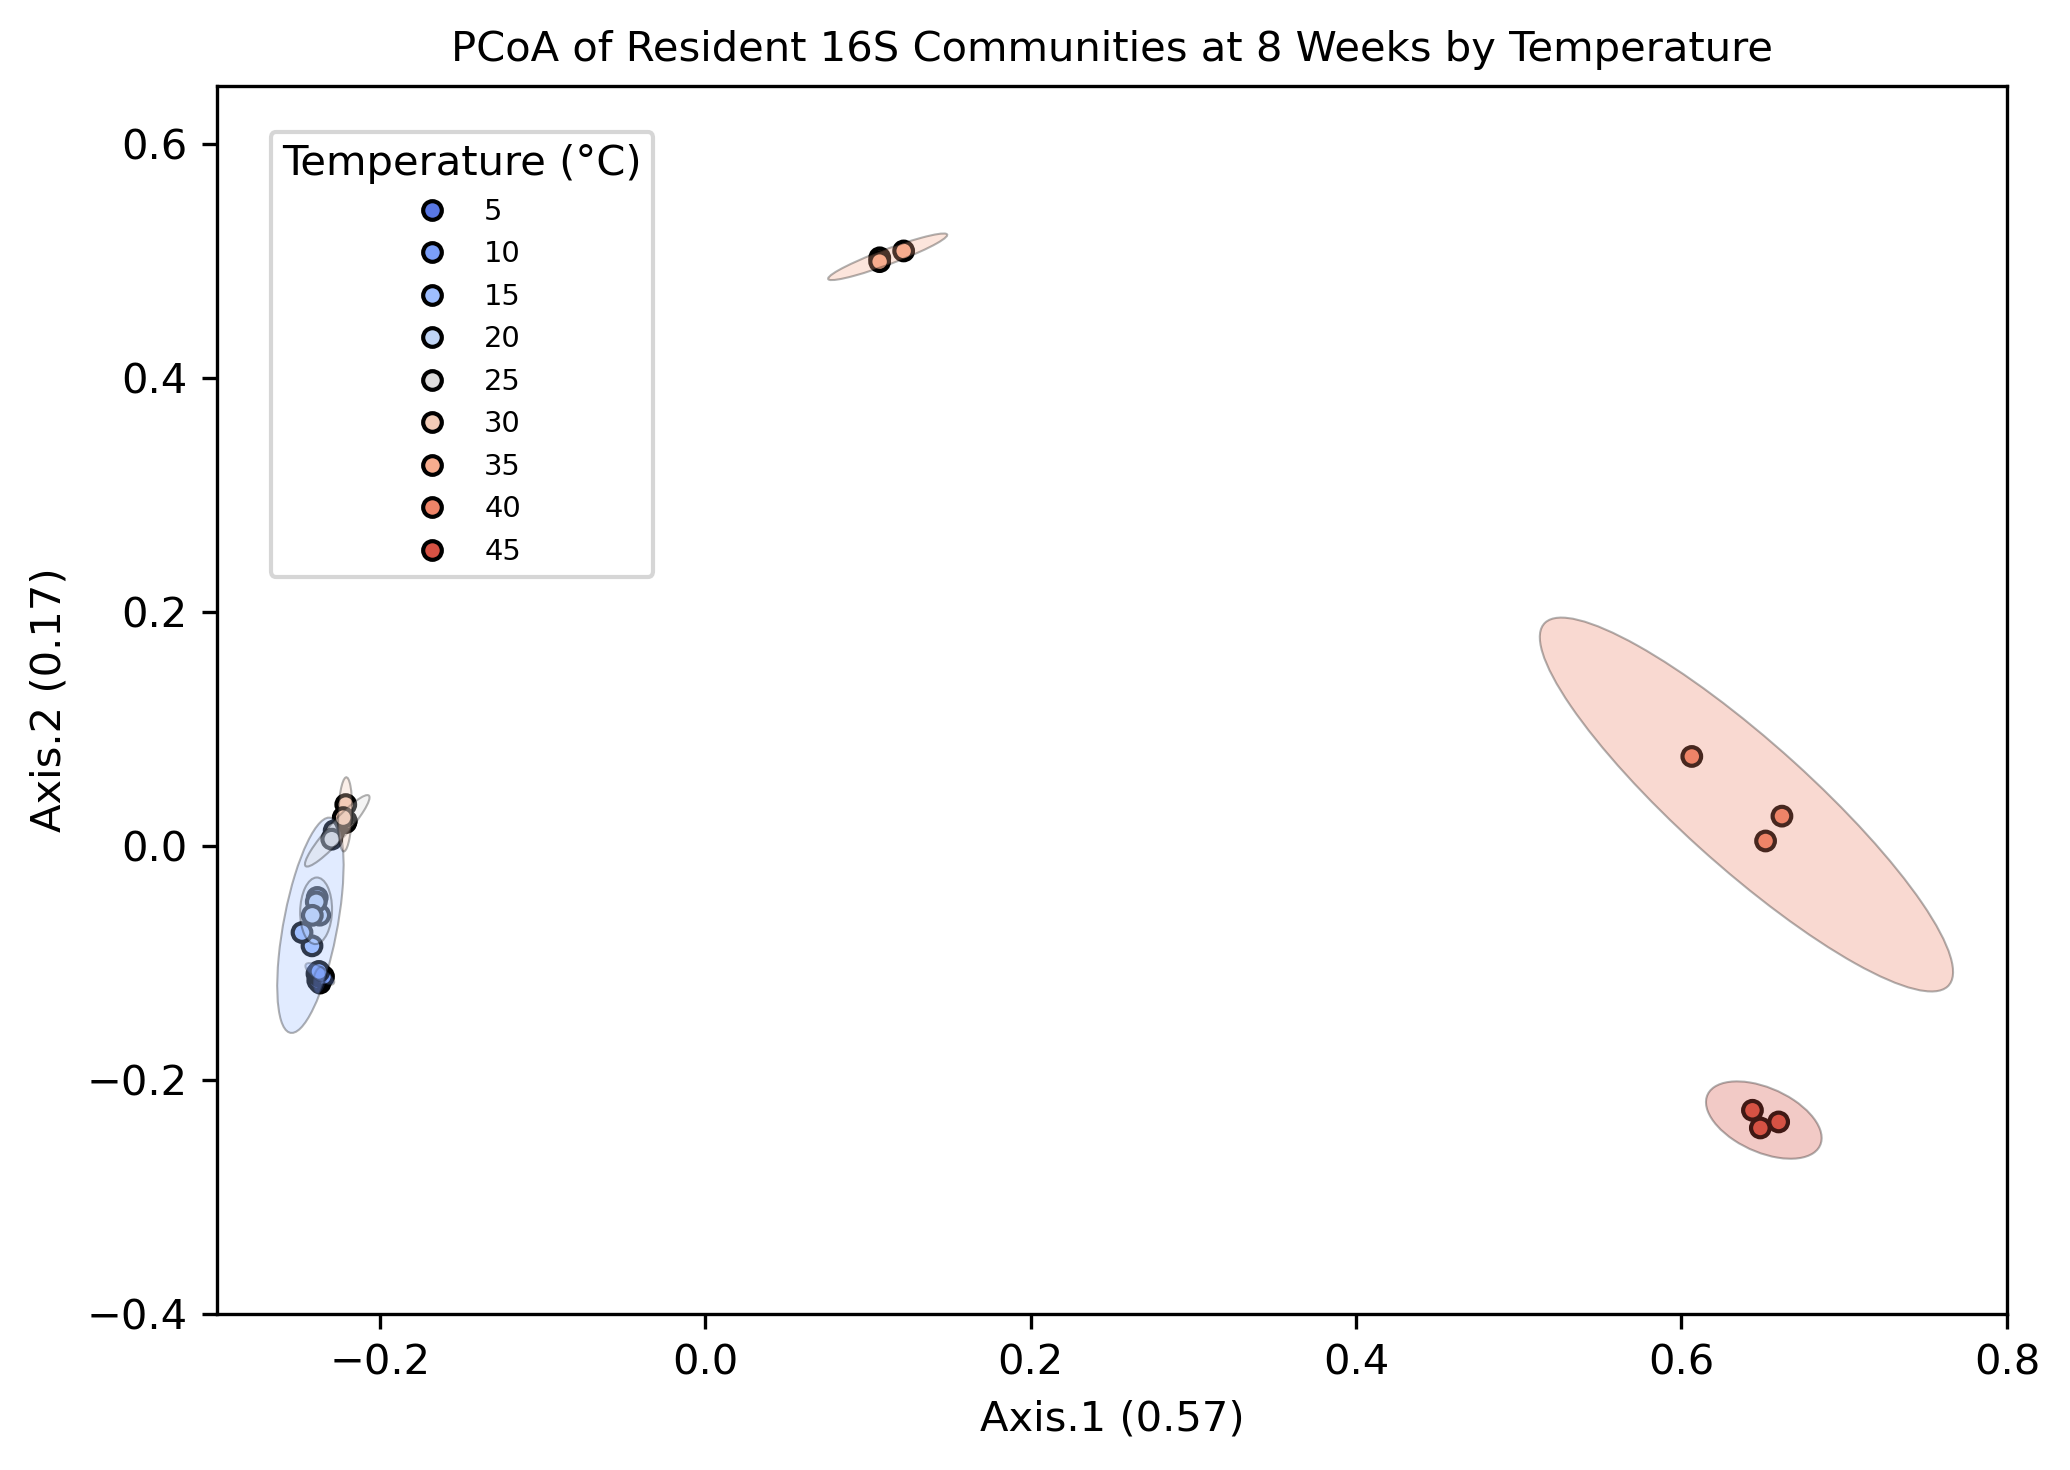

In [6]:
plot_data= s1_resident_w8_pcoa.copy()

# Create colour palette
colours = sns.color_palette('coolwarm',9)
colours = dict(zip(plot_data['Temperature'].unique(),colours))

# Plot
plt.figure(figsize= (7,5), dpi= 300)
p = sns.scatterplot(plot_data, x= plot_data.columns[1], y= plot_data.columns[2], hue= "Temperature", palette= colours,
               s= 20, linewidth= 1, edgecolor= 'Black')

# Add ellipses
for temperature in plot_data['Temperature'].unique():
    subset = plot_data[plot_data['Temperature'] == temperature]
    x = subset[subset.columns[1]]
    y = subset[subset.columns[2]]
    confidence_ellipse(x= x, y= y, n_std= 4.303, ax= p.axes, facecolor= colours[temperature], alpha= 0.3, edgecolor= 'black', linewidth= 0.5)

# Tidy up
plt.legend(title= "Temperature (°C)", loc = (0.03, 0.60), fontsize= 'x-small')
plt.xlim(-0.3, 0.8)
plt.ylim(-0.4, 0.65)
plt.title("PCoA of Resident 16S Communities at 8 Weeks by Temperature", fontsize= 'medium')
plt.tight_layout()

# Export to file
plt.savefig("../Figures/Diversity/Beta/StageOneResidentWeekEight_pcoa.png")


### PERMANOVA

In [19]:
%%R
# Read in data
data= read.csv("../Datasets/Diversity/Beta/StageOneResidentWeekEight_pcoa.csv")
metadata= read.csv("../Datasets/sample-data.csv")

# Filter metadata to samples of interest
metadata = metadata %>% filter(Stage == 1 & Time.point..week. == 8 & Active == 0)
metadata$Temperature = as.factor(metadata$Temperature)

#data = t(data)
rownames(data) = data$X
data$X = NULL

rownames(metadata) = metadata$Sample
rownames(data) = rownames(metadata)

# Run PERMANOVA
result = adonis2(data ~ Temperature, data= metadata, permutations= 999)

# Save to file
output = print(result)
capture.output(output, file= "../Datasets/Diversity/Beta/StageOneResidentWeekEight_PERMANOVA.txt")

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

adonis2(formula = data ~ Temperature, data = metadata, permutations = 999)
            Df SumOfSqs     R2      F Pr(>F)    
Temperature  8   6172.1 0.9994 3767.4  0.001 ***
Residual    18      3.7 0.0006                  
Total       26   6175.8 1.0000                  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


#
#### Strong evidence that temperature explains differences in community composition ($R^{2}$ = 0.9994, p = 0.001)*
#  

## PCoA of Active 16S Communities at Different Temperatures After 8 Weeks

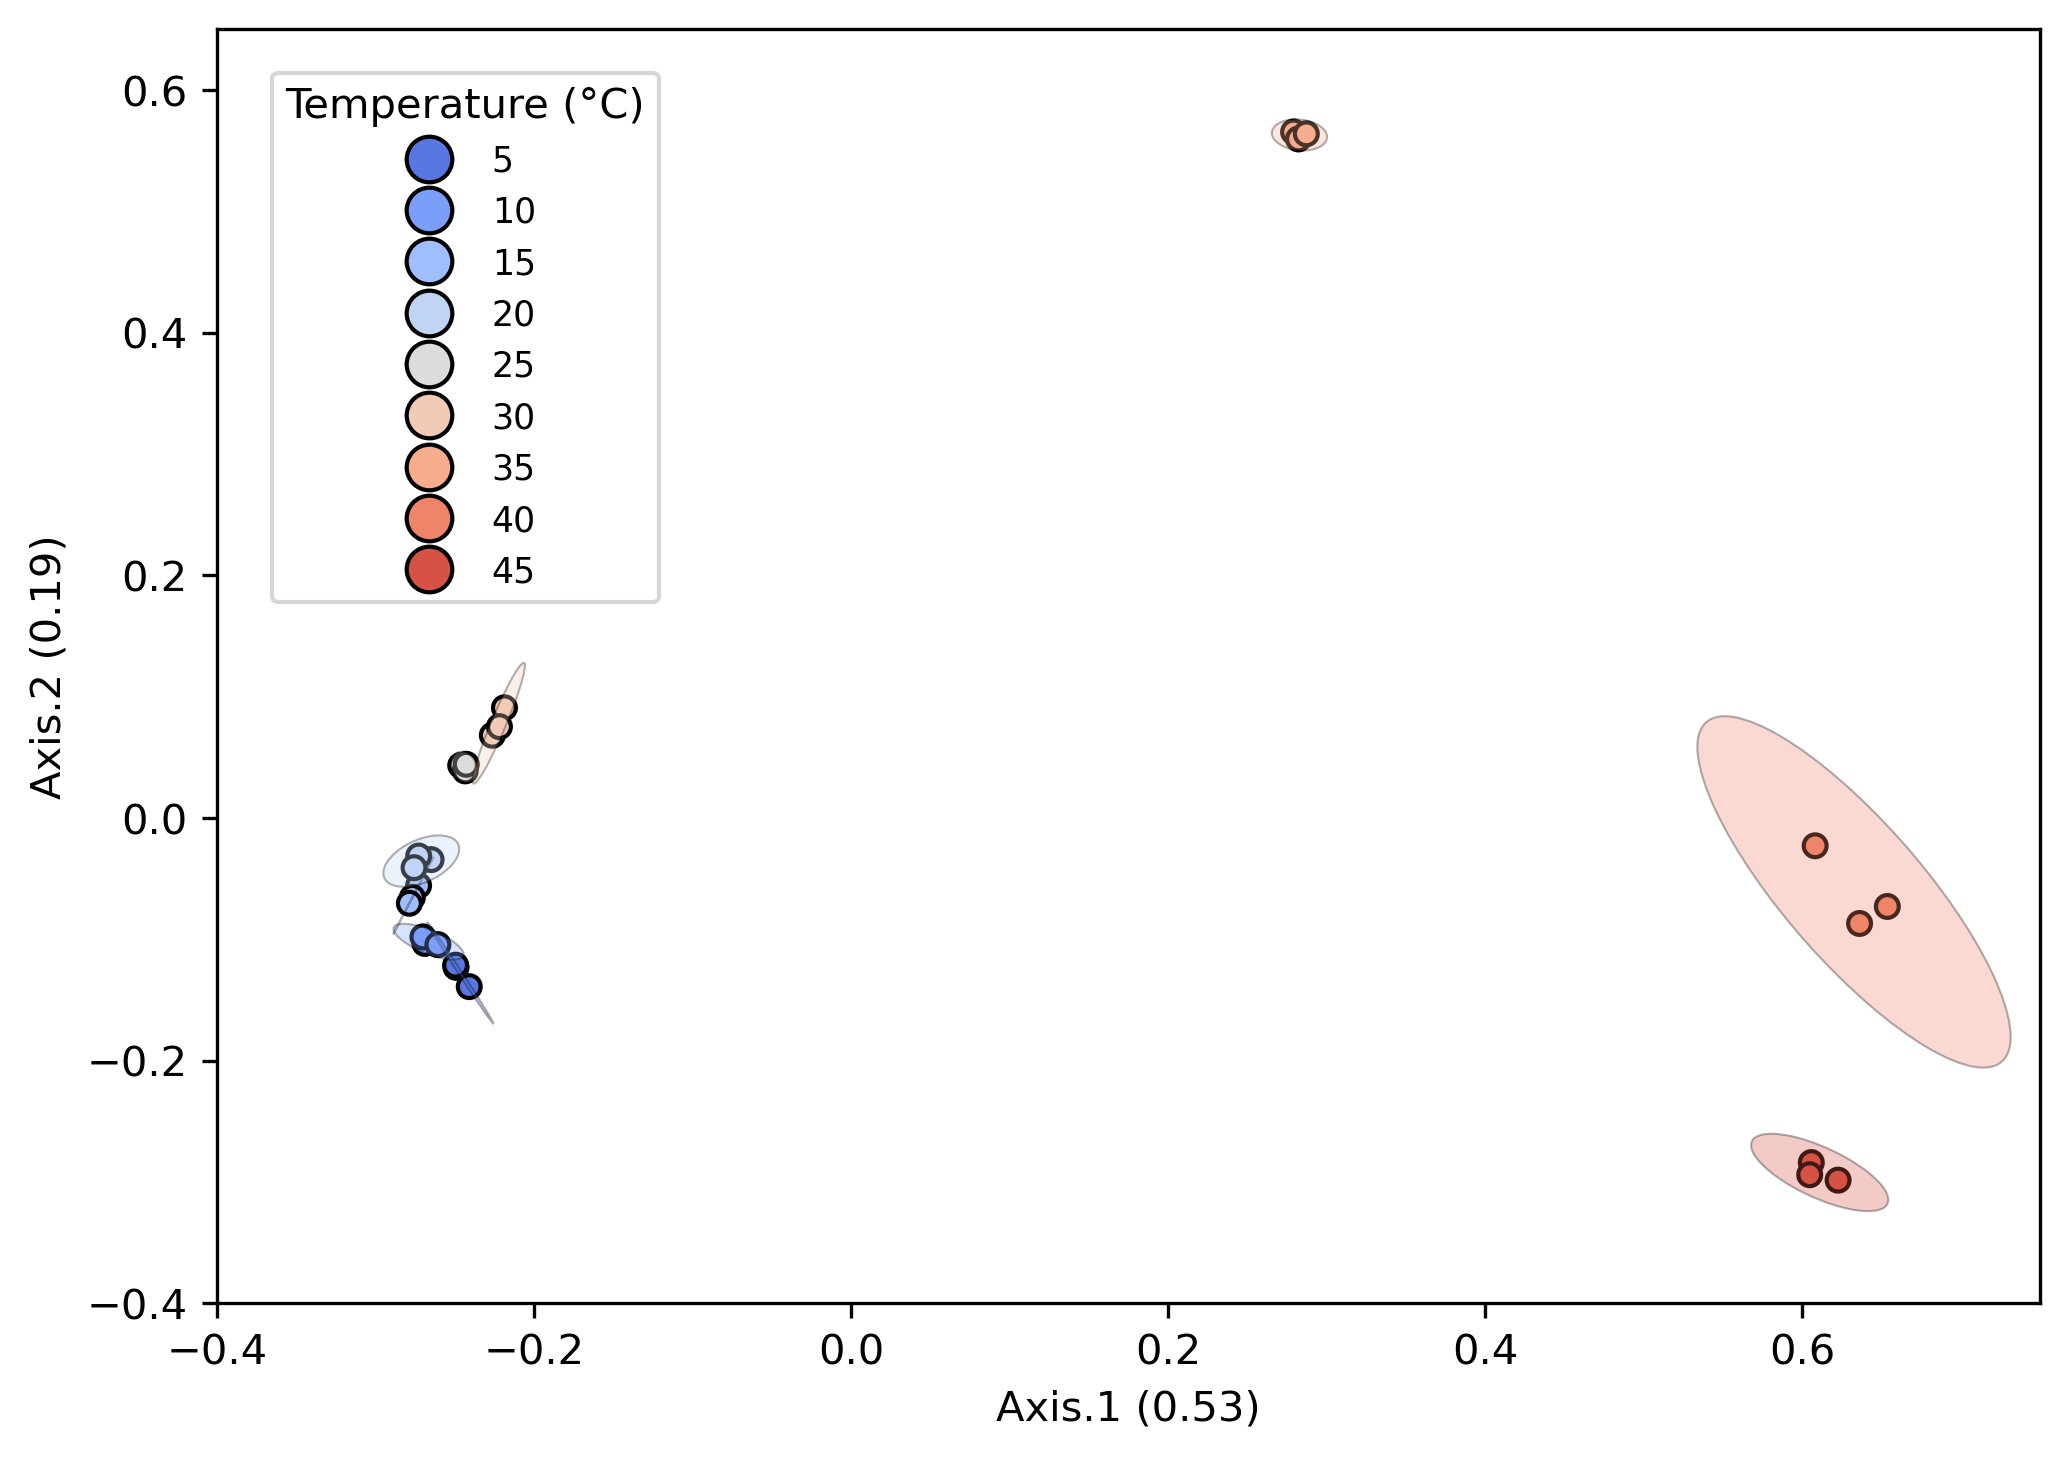

In [13]:
plot_data= s1_active_pcoa.copy()

# Create colour palette
colours = sns.color_palette('coolwarm',9)
colours = dict(zip(plot_data['Temperature'].unique(),colours))

# Plot
plt.figure(figsize= (7,5), dpi= 300)
p = sns.scatterplot(plot_data, x= plot_data.columns[1], y= plot_data.columns[2], hue= "Temperature", palette= colours,
               s= 30, linewidth= 1, edgecolor= 'Black')

# Add ellipses
for temperature in plot_data['Temperature'].unique():
    subset = plot_data[plot_data['Temperature'] == temperature]
    x = subset[subset.columns[1]]
    y = subset[subset.columns[2]]
    confidence_ellipse(x= x, y= y, n_std= 4.303, ax= p.axes, facecolor= colours[temperature], alpha= 0.3, edgecolor= 'black', linewidth= 0.5)

# Tidy up
plt.legend(title= "Temperature (°C)", loc = (0.03, 0.55), fontsize= 'small', markerscale= 2)
plt.xlim(-0.4, 0.75)
plt.ylim(-0.4, 0.65)
#plt.title("PCoA of Active 16S Communities at 8 Weeks by Temperature", fontsize= 'medium')
plt.tight_layout()

# Export to file
plt.savefig("../Figures/Diversity/Beta/StageOneActive_pcoa.png")

### PERMANOVA

In [18]:
%%R
# Read in data
data= read.csv("../Datasets/Diversity/Beta/StageOneActive_pcoa.csv")
metadata= read.csv("../Datasets/sample-data.csv")

# Filter metadata to samples of interest
metadata = metadata %>% filter(Stage == 1 & Time.point..week. == 8 & Active == 1)
metadata$Temperature = as.factor(metadata$Temperature)

#data = t(data)
rownames(data) = data$X
data$X = NULL

rownames(metadata) = metadata$Sample
rownames(data) = rownames(metadata)

# Run PERMANOVA
result = adonis2(data ~ Temperature, data= metadata, permutations= 999)

# Save to file
output = print(result)
capture.output(output, file= "../Datasets/Diversity/Beta/StageOneActive_PERMANOVA.txt")

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

adonis2(formula = data ~ Temperature, data = metadata, permutations = 999)
            Df SumOfSqs      R2      F Pr(>F)  
Temperature  8    33934 0.99677 694.26  0.038 *
Residual    18      110 0.00323                
Total       26    34044 1.00000                
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


#
#### Strong evidence that temperature explains differences in community composition ($R^{2}$ = 0.99677 , p = 0.038)*
#  

## PCoA of Resident 16S Communities Under Different Scales of Temperature Fluctuation

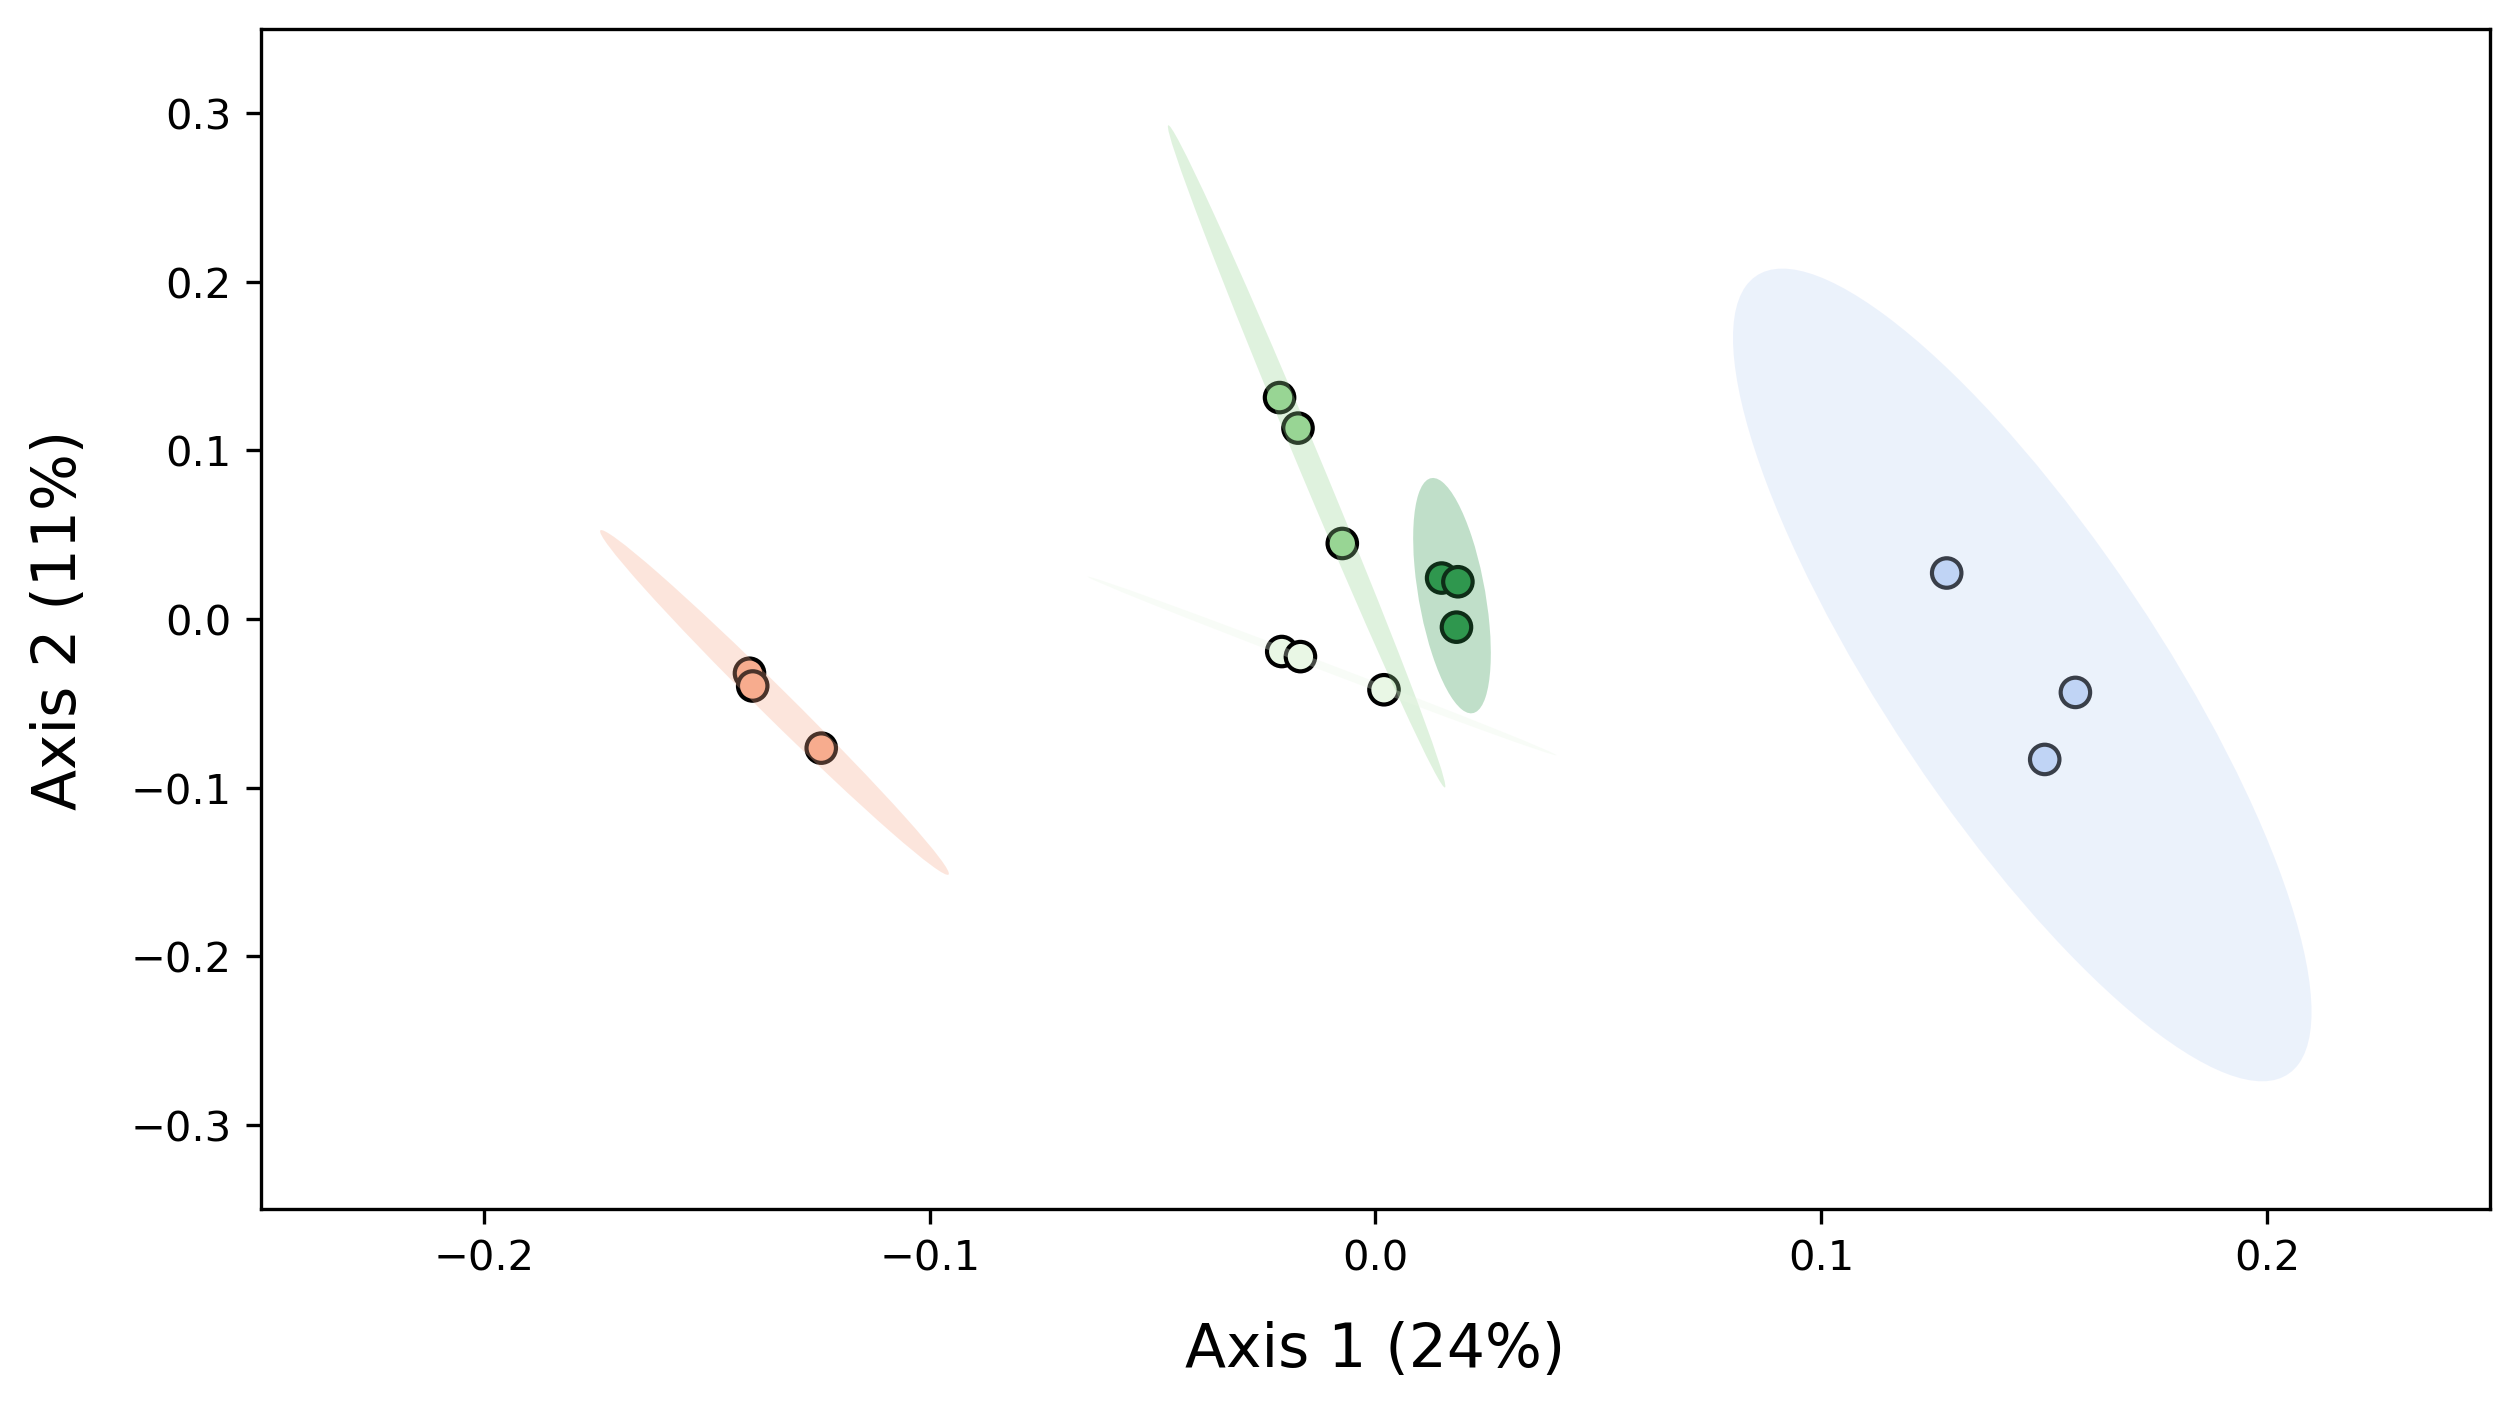

In [84]:
plot_data= s2_resident_w8_pcoa.copy()

# Create colour palette
colours = ['#c0d4f5', '#f7ac8e','#2f974e', '#98d594', '#e9f7e5']
labels = {'lowT':'15°C Stable','highT':'30°C Stable','2Weeks':'2-week Fluctuation','1Week':'1-week Fluctuation','2Days':'2-day Fluctuation'}
plot_data['Scale of fluctuation'] = plot_data['Scale of fluctuation'].map(labels)

# Create order for hue level
order = ['15°C Stable','30°C Stable','2-week Fluctuation','1-week Fluctuation','2-day Fluctuation']

# Plot
plt.figure(figsize= (8.5,4.8), dpi= 300)
p = sns.scatterplot(plot_data, x= plot_data.columns[1], y= plot_data.columns[2], hue= "Scale of fluctuation", hue_order= order,
                    palette= colours, s= 50, linewidth= 1, edgecolor= 'Black', legend= False)

# Add ellipses
for colour, scale in enumerate(order):
    subset = plot_data[plot_data['Scale of fluctuation'] == scale]
    x = subset[subset.columns[1]]
    y = subset[subset.columns[2]]
    confidence_ellipse(x= x, y= y, n_std= 4.303, ax= p.axes, facecolor= colours[colour], alpha= 0.3, edgecolor= None, linewidth= 0.5)

# Tidy up
#plt.legend(loc= (0.02,0.75), fontsize= 'xx-small', title= "Treatment")
plt.xlim(-0.25, 0.25)
plt.ylim(-0.35, 0.35)
# Manually set X and Y axis labels
plt.xlabel("Axis 1 (24%)", fontsize= 'x-large', labelpad= 10)
plt.ylabel("Axis 2 (11%)", fontsize= 'x-large', labelpad= 10)
#plt.title("PCoA of Resident 16S Communities Under\n Different Temperature Fluctuation Regimes", fontsize= 'medium')
plt.tight_layout()

# Export to file
plt.savefig("../Figures/Diversity/Beta/StageTwoResidentWeekEight_pcoa.png")

### PERMANOVA

In [34]:
%%R
# Read in data
data= read.csv("../Datasets/Diversity/Beta/StageTwoResidentWeekEight_pcoa.csv")
metadata= read.csv("../Datasets/sample-data.csv")

# Filter metadata to samples of interest
metadata = metadata %>% filter(Stage == 2 & Time.point..week. == 8 & Active == 0)
metadata$Scale.of.fluctuation = as.factor(metadata$Scale.of.fluctuation)

#data = t(data)
rownames(data) = data$X
data$X = NULL

rownames(metadata) = metadata$Sample
rownames(data) = rownames(metadata)

# Run PERMANOVA
result = adonis2(data ~ Scale.of.fluctuation, data= metadata, permutations= 999)

# Save to file
output = print(result)
capture.output(output, file= "../Datasets/Diversity/Beta/StageTwoResidentWeekEight_PERMANOVA.txt")

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

adonis2(formula = data ~ Scale.of.fluctuation, data = metadata, permutations = 999)
                     Df SumOfSqs      R2      F Pr(>F)
Scale.of.fluctuation  4    56133 0.98952 235.96   0.77
Residual             10      595 0.01048              
Total                14    56728 1.00000              


## PCoA of Active 16S Communities Under Different Scales of Temperature Fluctuation

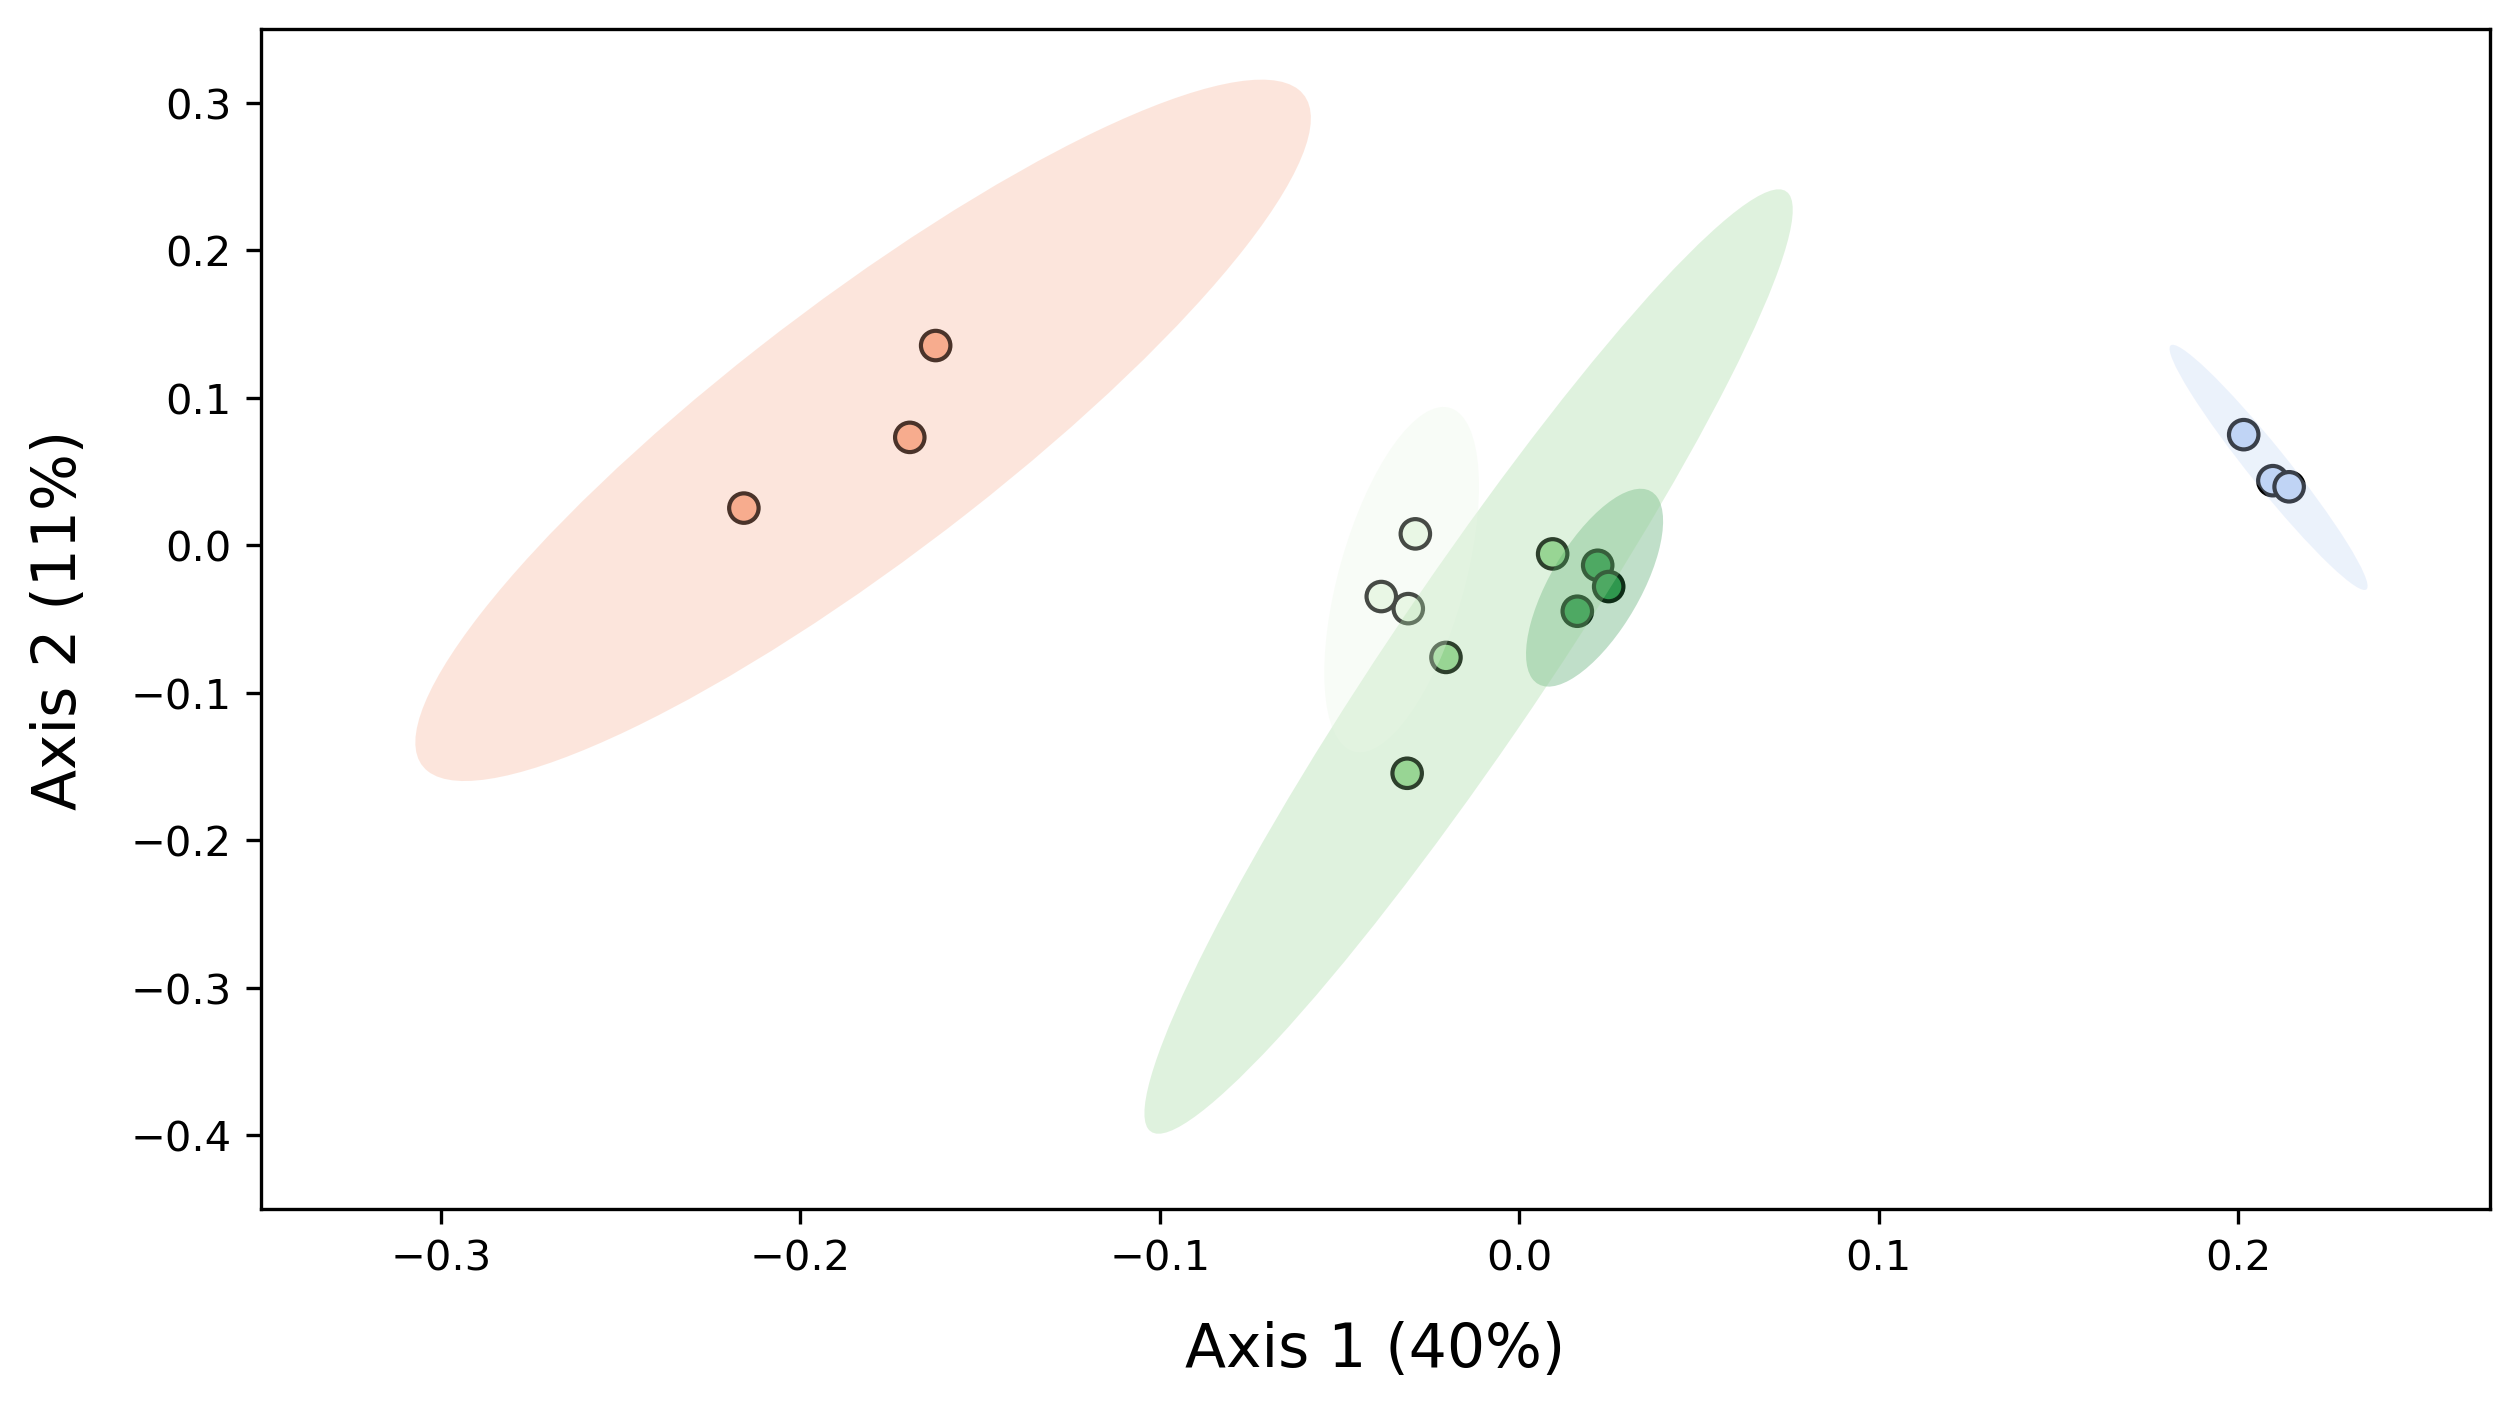

In [85]:
plot_data= s2_active_pcoa.copy()

# Create colour palette
colours = ['#c0d4f5', '#f7ac8e','#2f974e', '#98d594', '#e9f7e5']
labels = {'lowT':'15°C Stable','highT':'30°C Stable','2Weeks':'2-week Fluctuation','1Week':'1-week Fluctuation','2Days':'2-day Fluctuation'}
plot_data['Scale of fluctuation'] = plot_data['Scale of fluctuation'].map(labels)

# Create order for hue level
order = ['15°C Stable','30°C Stable','2-week Fluctuation','1-week Fluctuation','2-day Fluctuation']

# Plot
plt.figure(figsize= (8.5,4.8), dpi= 300)
p = sns.scatterplot(plot_data, x= plot_data.columns[1], y= plot_data.columns[2], hue= "Scale of fluctuation", hue_order= order,
                    palette= colours, s= 50, linewidth= 1, edgecolor= 'Black', legend= False)

# Add ellipses
for colour, scale in enumerate(order):
    subset = plot_data[plot_data['Scale of fluctuation'] == scale]
    x = subset[subset.columns[1]]
    y = subset[subset.columns[2]]
    confidence_ellipse(x= x, y= y, n_std= 4.303, ax= p.axes, facecolor= colours[colour], alpha= 0.3, edgecolor= None, linewidth= 0.5)

## Tidy up
#plt.legend(loc= (0.7,0.01), fontsize= 'large', frameon= False, markerscale= 2)
plt.xlim(-0.35, 0.27)
plt.ylim(-0.45, 0.35)
# Manually set X and Y axis labels
plt.xlabel("Axis 1 (40%)", fontsize= 'x-large', labelpad= 10)
plt.ylabel("Axis 2 (11%)", fontsize= 'x-large', labelpad= 10)
#plt.title("PCoA of Active 16S Communities Under\n Different Temperature Fluctuation Regimes", fontsize= 'medium')
plt.tight_layout()

# Export to file
plt.savefig("../Figures/Diversity/Beta/StageTwoActive_pcoa.png")

### PERMANOVA

In [94]:
%%R
# Read in data
data= read.csv("../Datasets/Diversity/Beta/StageTwoActive_pcoa.csv")
metadata= read.csv("../Datasets/sample-data.csv")

# Filter metadata to samples of interest
metadata = metadata %>% filter(Stage == 2 & Time.point..week. == 8 & Active == 1)
metadata$Scale.of.fluctuation = as.factor(metadata$Scale.of.fluctuation)

#data = t(data)
rownames(data) = data$X
data$X = NULL

rownames(metadata) = metadata$Sample
rownames(data) = rownames(metadata)

# Run PERMANOVA
result = adonis2(data ~ Scale.of.fluctuation, data= metadata, permutations= 999)

# Save to file
output = print(result)
capture.output(output, file= "../Datasets/Diversity/Beta/StageTwoActive_PERMANOVA.txt")

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

adonis2(formula = data ~ Scale.of.fluctuation, data = metadata, permutations = 999)
                     Df SumOfSqs      R2      F Pr(>F)   
Scale.of.fluctuation  4  2735.39 0.98517 166.11  0.005 **
Residual             10    41.17 0.01483                 
Total                14  2776.56 1.00000                 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


#
#### Strong evidence that scale of temperature fluctuation explains differences in community composition ($R^{2}$= 0.98517  , p= 0.004)
#  

---

## Variance Explained by Principal Component in Active Versus Resident Data

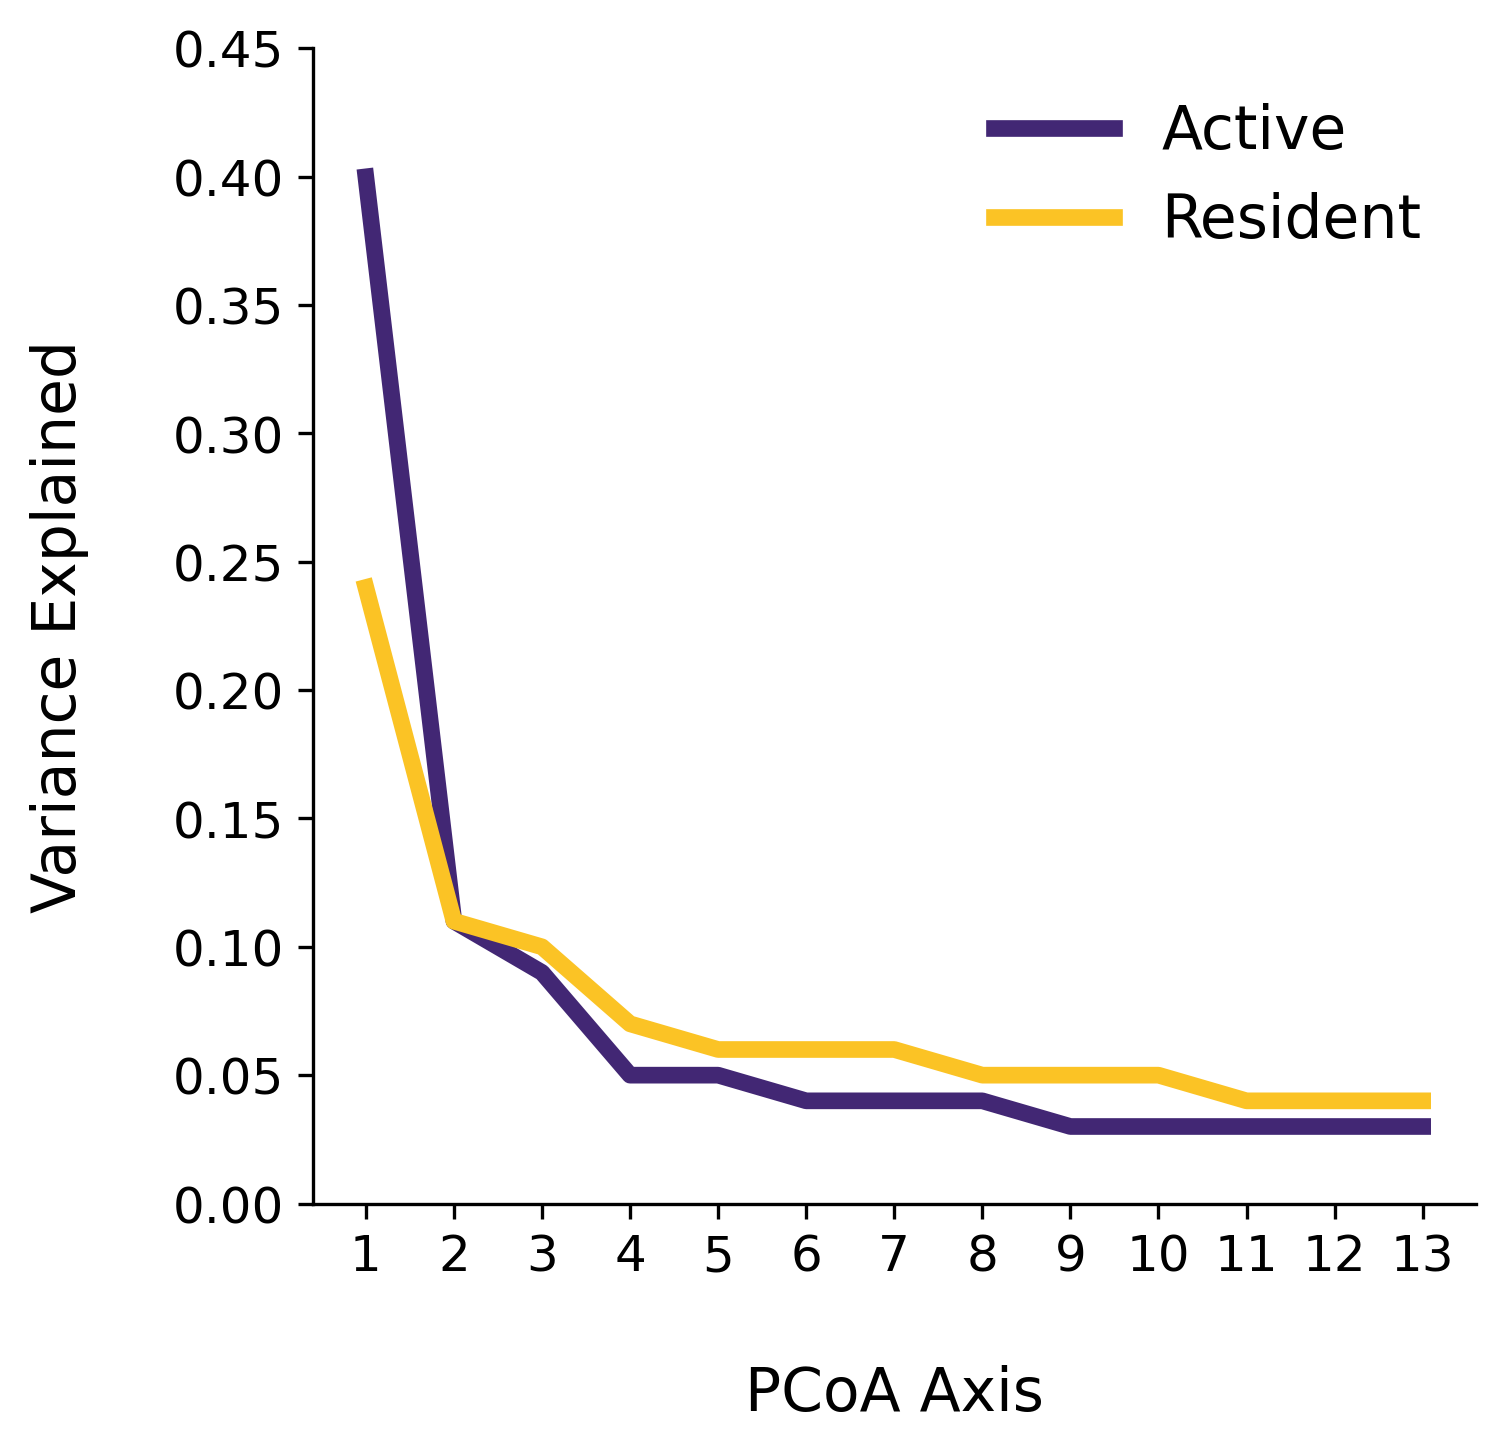

In [17]:
# Import PCoA data
s2_resident_w8_pcoa = pd.read_csv("../Datasets/Diversity/Beta/StageTwoResidentWeekEight_pcoa.csv")
s2_active_pcoa = pd.read_csv("../Datasets/Diversity/Beta/StageTwoActive_pcoa.csv")

# Extract variance explained from imported PCoA data
resident = [float(re.search(r'\(([\d.]+)\)', item).group(1)) for item in s2_resident_w8_pcoa.columns[1:-1]]
active = [float(re.search(r'\(([\d.]+)\)', item).group(1)) for item in s2_active_pcoa.columns[1:-1]]

# Make dataframe to hold values of variance explained
PCoA_variance = pd.DataFrame()
PCoA_variance['Axis'] = ['Axis ' + str(i) for i in range(1,len(active)+1)]
PCoA_variance['Active'] = active
PCoA_variance['Resident'] = resident

# Convert to long format
PCoA_variance = PCoA_variance.melt(value_vars= ['Active', 'Resident'], id_vars= 'Axis', var_name= 'Type', value_name= 'Variance')

# Plot variance explained by axis for each type
plt.figure(figsize= (5,5), dpi= 300)
p = sns.lineplot(data= PCoA_variance, x= 'Axis', y= 'Variance', hue= 'Type', palette= ['#422774', '#FBC325'], linewidth= 4)

# Tidy up
p.legend(loc= 1, frameon= False, fontsize= 'x-large')
p.set_xticks(ticks= p.get_xticks(), labels= range(1,len(active)+1), fontsize = 'large')
p.set_yticks(ticks= p.get_yticks(), labels= [f"{tick:.2f}" for tick in p.get_yticks()], fontsize= 'large')
plt.ylabel('Variance Explained', fontsize= 'x-large', labelpad= 20)
plt.xlabel('PCoA Axis', fontsize= 'x-large', labelpad= 20)
sns.despine()

# Export to file
plt.savefig("../Figures/Diversity/Beta/Variance_by_PCo_Resident_vs_Active.png");

## Cumulative Variance Explained by Principal Component in Active Versus Resident Data

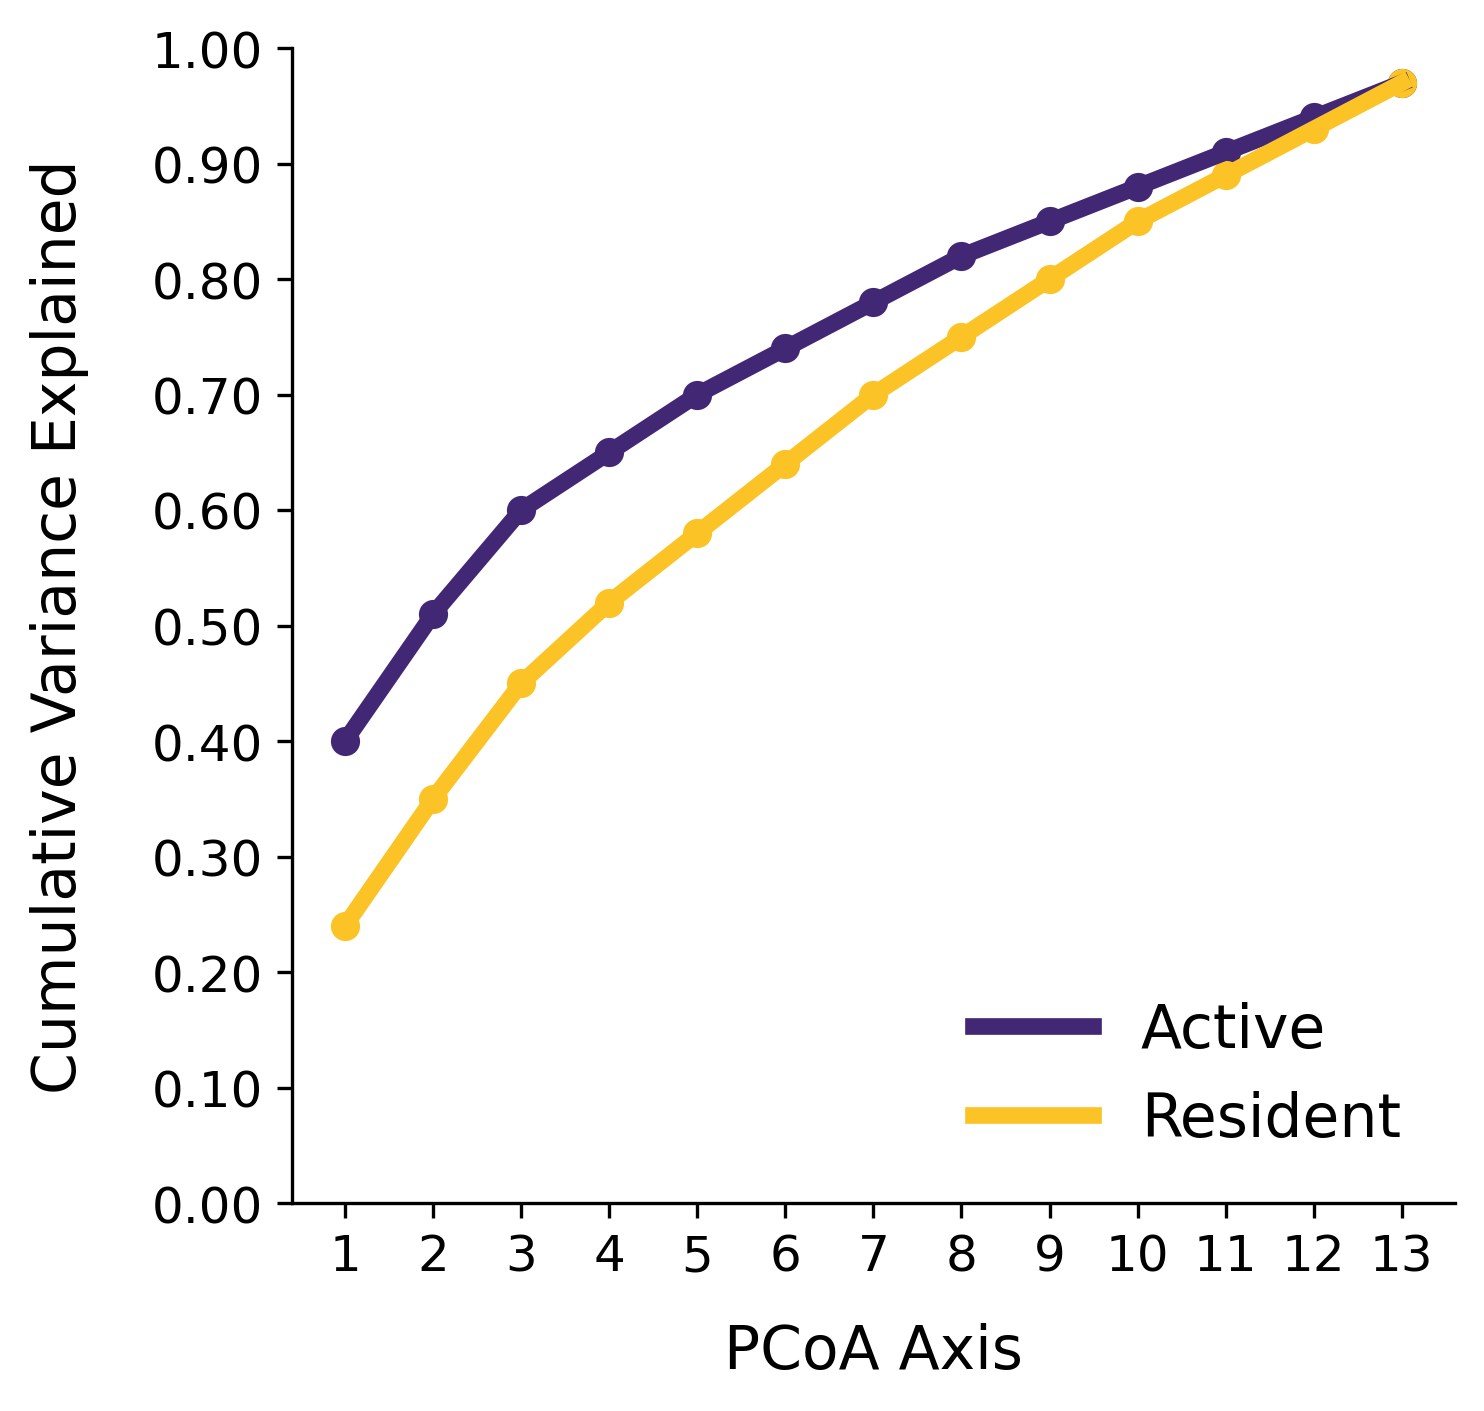

In [53]:
# Import PCoA data
s2_resident_w8_pcoa = pd.read_csv("../Datasets/Diversity/Beta/StageTwoResidentWeekEight_pcoa.csv")
s2_active_pcoa = pd.read_csv("../Datasets/Diversity/Beta/StageTwoActive_pcoa.csv")

# Extract variance explained from imported PCoA data
resident = [float(re.search(r'\(([\d.]+)\)', item).group(1)) for item in s2_resident_w8_pcoa.columns[1:-1]]
resident = [sum(resident[:i+1]) for i,variance in enumerate(resident)]
active = [float(re.search(r'\(([\d.]+)\)', item).group(1)) for item in s2_active_pcoa.columns[1:-1]]
active = [sum(active[:i+1]) for i,variance in enumerate(active)]

# Make dataframe to hold values of variance explained
PCoA_variance = pd.DataFrame()
PCoA_variance['Axis'] = ['Axis ' + str(i) for i in range(1,len(active)+1)]
PCoA_variance['Active'] = active
PCoA_variance['Resident'] = resident

# Convert to long format
PCoA_variance = PCoA_variance.melt(value_vars= ['Active', 'Resident'], id_vars= 'Axis', var_name= 'Type', value_name= 'Variance')

# Plot variance explained by axis for each type
plt.figure(figsize= (5,5), dpi= 300)
p = sns.lineplot(data= PCoA_variance, x= 'Axis', y= 'Variance', hue= 'Type', palette= ['#422774', '#FBC325'], linewidth= 4)
p.scatter(data= PCoA_variance.query("`Type` == 'Active'"), x= 'Axis', y= 'Variance', c= '#422774') # Points for active curve
p.scatter(data= PCoA_variance.query("`Type` == 'Resident'"), x= 'Axis', y= 'Variance', c= '#FBC325') # Points for resident curve


# Tidy up
p.legend(loc= 4, frameon= False, fontsize= 'x-large', handles= p.get_legend_handles_labels()[0][:2])
p.set_xticks(ticks= p.get_xticks(), labels= range(1,len(active)+1), fontsize = 'large')
p.set_yticks(np.linspace(0,1,11), labels= [f"{num:.2f}" for num in np.linspace(0,1,11,)], fontsize= 'large')
p.set_ylim((0,1))
plt.ylabel('Cumulative Variance Explained', fontsize= 'x-large', labelpad= 15)
plt.xlabel('PCoA Axis', fontsize= 'x-large', labelpad= 10)
sns.despine()

# Export to file
plt.savefig("../Figures/Diversity/Beta/Cumulative_Variance_by_PCo_Resident_vs_Active.png");

---

## PCoA of Resident Communities Under Different Scales of Temperature Fluctuation Over Time

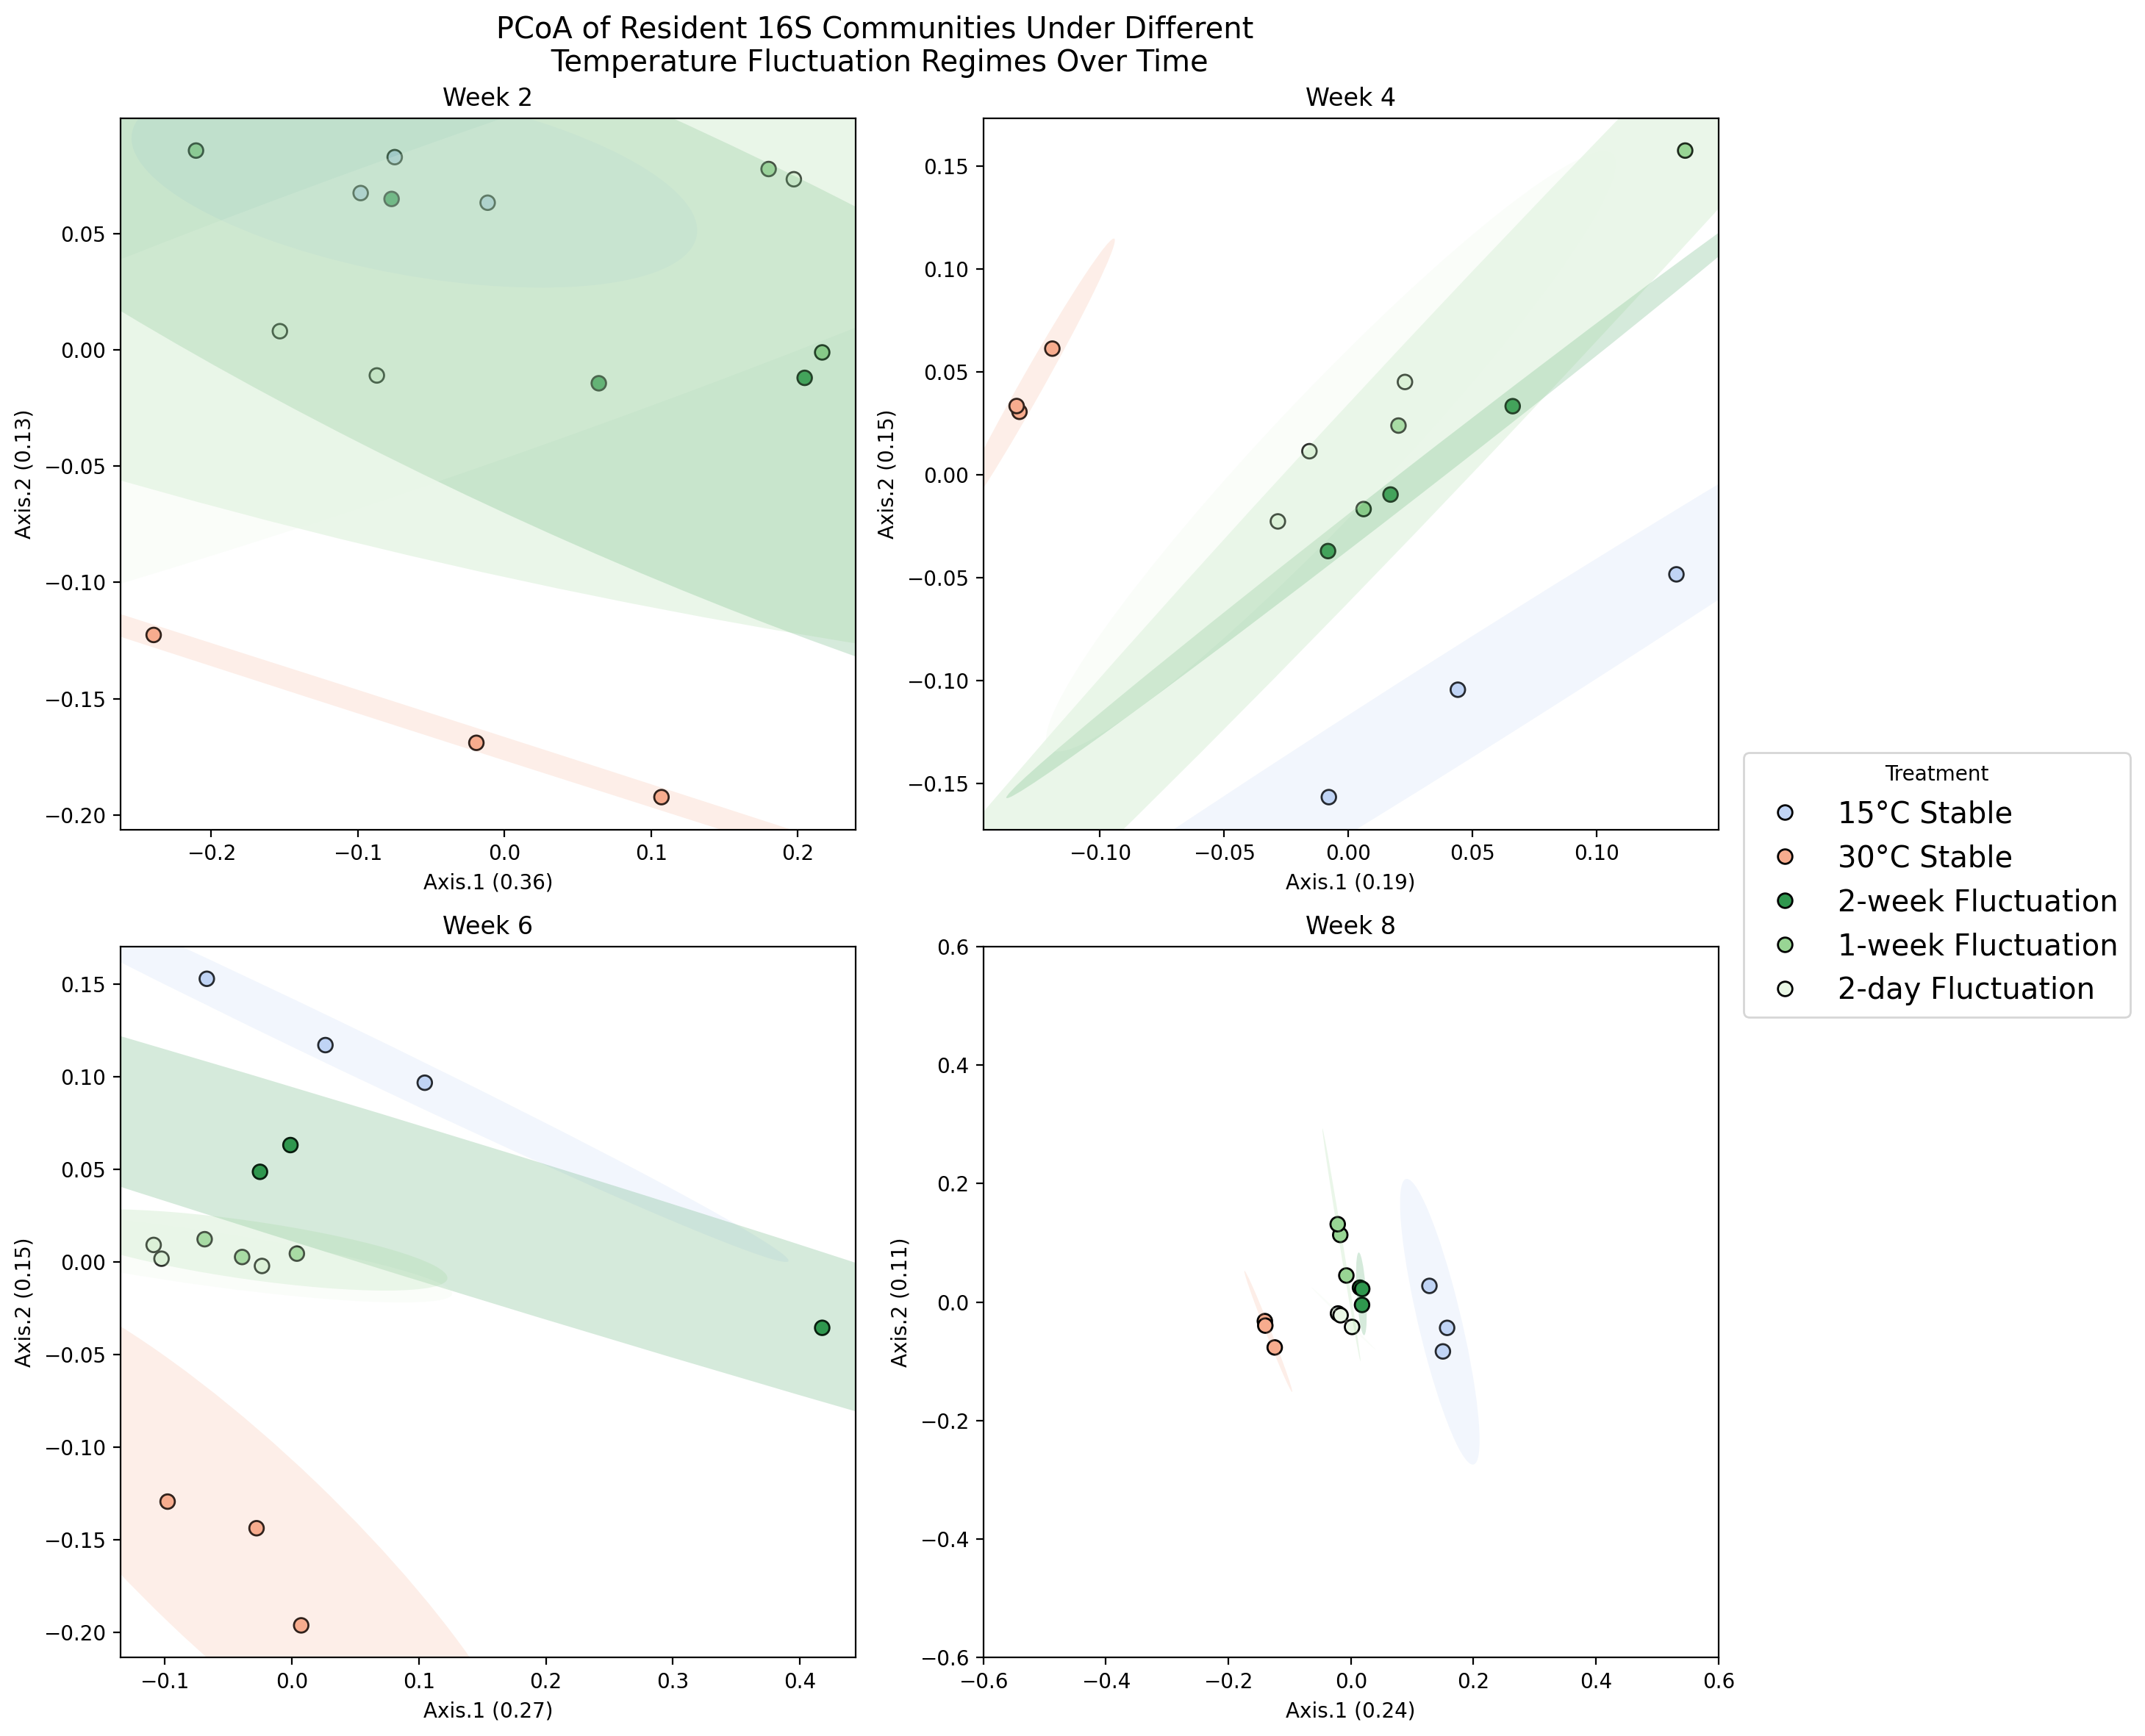

In [10]:
# Set up subplots
fig,axes = plt.subplots(ncols=2, nrows= 2, figsize= (12,12), dpi= 200, sharex= False, sharey= False)

# Set up datasets and subplot coordinates
datasets = [s2_resident_w2_pcoa,s2_resident_w4_pcoa,s2_resident_w6_pcoa,s2_resident_w8_pcoa]
subplots = [(0,0),(0,1),(1,0),(1,1)]

# Create colour palette
colours = ['#c0d4f5', '#f7ac8e','#2f974e', '#98d594', '#e9f7e5']
labels = {'lowT':'15°C Stable','highT':'30°C Stable','2Weeks':'2-week Fluctuation','1Week':'1-week Fluctuation','2Days':'2-day Fluctuation'}

# Create order for hue level
order = ['15°C Stable','30°C Stable','2-week Fluctuation','1-week Fluctuation','2-day Fluctuation']

# Create titles for each subplot
titles = ['Week 2', 'Week 4', 'Week 6', 'Week 8']

for subplot,dataset in enumerate(datasets):
        
    plot_data= dataset.copy()

    # Get subplot coordinates
    v = subplots[subplot][0]
    h = subplots[subplot][1]
    
    # Rename Scale of fluctuation variables for plotting
    plot_data['Scale of fluctuation'] = plot_data['Scale of fluctuation'].map(labels)
    
    # Plot
    p = sns.scatterplot(plot_data, x= plot_data.columns[1], y= plot_data.columns[2], hue= "Scale of fluctuation", hue_order= order,
                        palette= colours, s= 50, linewidth= 1, edgecolor= 'Black', ax= axes[v][h])
    
    # Add ellipses
    for colour, scale in enumerate(order):
        subset = plot_data[plot_data['Scale of fluctuation'] == scale]
        x = subset[subset.columns[1]]
        y = subset[subset.columns[2]]
        confidence_ellipse(x= x, y= y, n_std= 4.303, ax= p.axes, facecolor= colours[colour], alpha= 0.2, edgecolor= None, linewidth= 0.5)

    # Tidy up
    p.set_title(titles[subplot], fontsize= 12)
    p.set_xlabel(plot_data.columns[1], fontsize= 10)
    p.set_ylabel(plot_data.columns[2], fontsize= 10)
    p.tick_params(labelsize= 10)
    axes[v][h].get_legend().remove()

# Tidy up
plt.xlim(-0.6, 0.6)
plt.ylim(-0.6, 0.6)
handles, labels = axes[1][1].get_legend_handles_labels()
fig.legend(handles, labels, fontsize= "x-large", title= "Treatment", bbox_to_anchor=(1.22, 0.57))
plt.suptitle("PCoA of Resident 16S Communities Under Different\n Temperature Fluctuation Regimes Over Time", fontsize= 'x-large')
plt.tight_layout()

# Export to file
plt.savefig("../Figures/Diversity/Beta/StageTwoResidentAllWeeks_pcoa.png")

### PERMANOVA

In [86]:
%%R
# Read in data
data= read.csv("../Datasets/Diversity/Beta/StageTwoResidentWeekTwo_pcoa.csv")
metadata= read.csv("../Datasets/sample-data.csv")

# Filter metadata to samples of interest
metadata = metadata %>% filter(Stage == 2 & Time.point..week. == 2 & Active == 0)
metadata$Scale.of.fluctuation = as.factor(metadata$Scale.of.fluctuation)

rownames(data) = data$X
data$X = NULL

rownames(metadata) = metadata$Sample
rownames(data) = rownames(metadata)

# Run PERMANOVA
result = adonis2(data ~ Scale.of.fluctuation, data= metadata, permutations= 999)

# Save to file
output = print(result)
capture.output(output, file= "../Datasets/Diversity/Beta/StageTwoResidentWeekTwo_PERMANOVA.txt")

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

adonis2(formula = data ~ Scale.of.fluctuation, data = metadata, permutations = 999)
                     Df SumOfSqs      R2      F Pr(>F)  
Scale.of.fluctuation  4   665.62 0.93713 37.265   0.09 .
Residual             10    44.66 0.06287                
Total                14   710.28 1.00000                
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [93]:
Weeks = {'Two': 2, 'Four': 4, 'Six': 6, 'Eight': 8}
R2_values = []

for week in Weeks.keys():
    ro.r(f"""
    # Read in data
    data= read.csv("../Datasets/Diversity/Beta/StageTwoResidentWeek{week}_pcoa.csv")
    metadata= read.csv("../Datasets/sample-data.csv")

    # Filter metadata to samples of interest
    metadata = metadata %>% filter(Stage == 2 & Time.point..week. == {Weeks[week]} & Active == 0)
    metadata$Scale.of.fluctuation = as.factor(metadata$Scale.of.fluctuation)

    # Format data
    rownames(data) = data$X
    data$X = NULL
    rownames(metadata) = metadata$Sample
    rownames(data) = rownames(metadata)

    # Run PERMANOVA
    result = adonis2(data ~ Scale.of.fluctuation, data= metadata, permutations= 999)

    # Save to file
    output = print(result)
    capture.output(output, file= "../Datasets/Diversity/Beta/StageTwoResidentWeek{week}_PERMANOVA.txt")
    """)
    R2_values.append([Weeks[week],np.round(float(ro.r("result$R2[[1]]")),2)])

pd.DataFrame(R2_values, columns= ['Week','R2'])

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

adonis2(formula = data ~ Scale.of.fluctuation, data = metadata, permutations = 999)
                     Df SumOfSqs      R2      F Pr(>F)
Scale.of.fluctuation  4   665.62 0.93713 37.265   0.11
Residual             10    44.66 0.06287              
Total                14   710.28 1.00000              
Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

adonis2(formula = data ~ Scale.of.fluctuation, data = metadata, permutations = 999)
                     Df SumOfSqs      R2     F Pr(>F)
Scale.of.fluctuation  4  131.742 0.64574 4.557  0.218
Residual             10   72.274 0.35426             
Total                14  204.016 1.00000             
Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permuta

,Week,R2
0,2,0.94
1,4,0.65
2,6,-3.34
3,8,0.99


# 
---
# 

# Beta Dispersion Within Groups

## Stage 2 Resident (Week 8)

In [4]:
%%R

# Read in Sequence Table
data = read.csv("../Datasets/SequenceTables/StageTwoResidentWeekEight.csv",sep = ',')

# Set index to samples
rownames(data) = data$ASV_ID
data$ASV_ID = NULL
data = t(data)

# Calculate size to subset to
size = min(rowSums(data))

# Calculate Bray-Curtis Dissimilarity between samples
community_distances = avgdist(x= data, sample= size, dmethod= 'bray')

# Read in Metadata
metadata= read.csv("../Datasets/sample-data.csv")

# Filter metadata to samples of interest
metadata = metadata %>% filter(Stage == 2 & Time.point..week. == 8 & Active == 0)
metadata$Scale.of.fluctuation = as.factor(metadata$Scale.of.fluctuation)

rownames(metadata) = metadata$Sample


# # Calculate beta dispersion
result = betadisper(d= community_distances, group= metadata$Scale.of.fluctuation)
result = data.frame(result$distances)
write.csv(result, "../Datasets/Diversity/Beta/StageTwoResidentWeekEight_dispersion.csv")


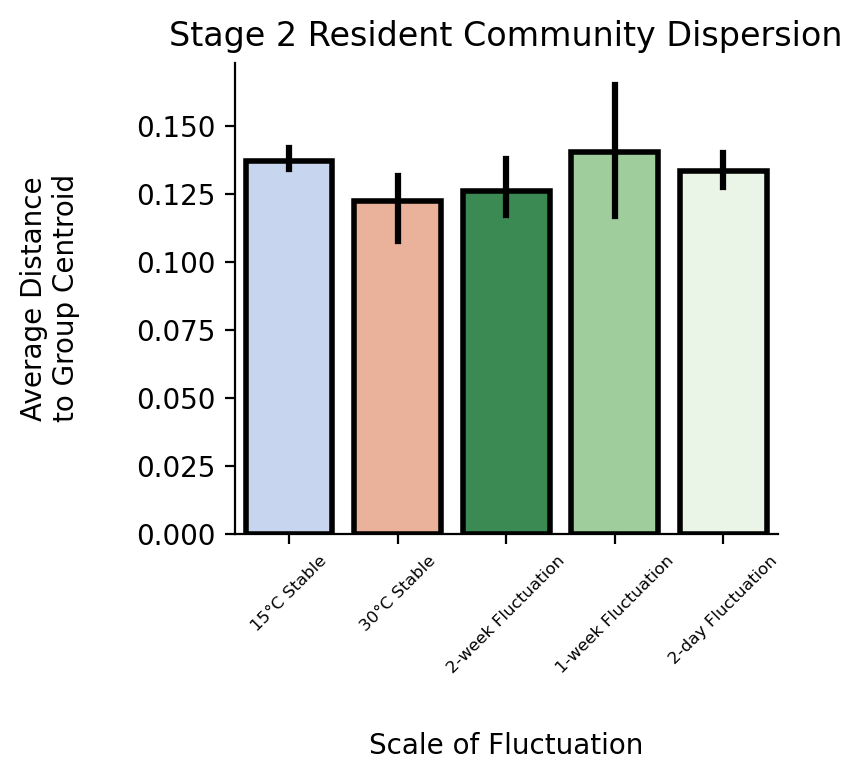

In [5]:
df = pd.read_csv("../Datasets/Diversity/Beta/StageTwoResidentWeekEight_dispersion.csv")
df.columns= ['Sample', 'Distance']
df['Sample'] = [sample[1:] for sample in df['Sample']]    # Remove 'X' from sample numbers
df = pd.merge(left= df, right= sample_data, how= 'left', on= 'Sample')


# Create colour palette
colours = ['#c0d4f5', '#f7ac8e','#2f974e', '#98d594', '#e9f7e5']
labels = {'lowT':'15°C Stable','highT':'30°C Stable','2Weeks':'2-week Fluctuation','1Week':'1-week Fluctuation','2Days':'2-day Fluctuation'}

df['Scale of fluctuation'] = df['Scale of fluctuation'].map(labels)

# Plot
plt.figure(figsize= (4,4), dpi= 200)
plot = sns.barplot(data= df, x= 'Scale of fluctuation', y= 'Distance', order= labels.values(), palette= colours, linewidth= 2, edgecolor= 'black',
           err_kws= {'color': 'black'})

# Tidy up
plt.xticks(rotation= 45, fontsize= 6)
plt.xlabel('Scale of Fluctuation',fontsize= 10, labelpad= 20)
plt.ylabel('Average Distance\nto Group Centroid',fontsize= 10, labelpad= 20)
plt.title("Stage 2 Resident Community Dispersion")
sns.despine()
plt.tight_layout()

# Save to file
plt.savefig("../Figures/Diversity/Beta/StageTwoResidentWeekEight_dispersion.png")

## Stage 2 Active

### Calculate Beta Dispersion

In [6]:
%%R

# Read in Sequence Table
data = read.csv("../Datasets/SequenceTables/StageTwoActive.csv",sep = ',')

# Set index to samples
rownames(data) = data$ASV_ID
data$ASV_ID = NULL
data = t(data)

# Calculate size to subset to
size = min(rowSums(data))

# Calculate Bray-Curtis Dissimilarity between samples
community_distances = avgdist(x= data, sample= size, dmethod= 'bray')

# Read in Metadata
metadata= read.csv("../Datasets/sample-data.csv")

# Filter metadata to samples of interest
metadata = metadata %>% filter(Stage == 2 & Time.point..week. == 8 & Active == 1)
metadata$Scale.of.fluctuation = as.factor(metadata$Scale.of.fluctuation)

rownames(metadata) = metadata$Sample

# # Calculate beta dispersion
result = betadisper(d= community_distances, group= metadata$Scale.of.fluctuation)
result = data.frame(result$distances)
write.csv(result, "../Datasets/Diversity/Beta/StageTwoActive_dispersion.csv")

### Test for normality of data within groups

In [4]:
# Import data into R
s2_active_dispersion = pd.read_csv("../Datasets/Diversity/Beta/StageTwoActive_dispersion.csv")
s2_active_dispersion.columns= ['Sample', 'Distance']
s2_active_dispersion['Sample'] = [sample[1:] for sample in s2_active_dispersion['Sample']]    # Remove 'X' from sample numbers
s2_active_dispersion = pd.merge(left= s2_active_dispersion, right= sample_data, how= 'left', on= 'Sample')
ro.globalenv['data'] = s2_active_dispersion

In [5]:
%%R

data = data %>% rename(Scale.of.fluctuation = "Scale of fluctuation")

In [6]:
%%R

# Loop through each group and apply the Shapiro-Wilk test
shapiro_results <- by(data$Distance, data$Scale.of.fluctuation, shapiro.test)

# Print results
print(shapiro_results[[1]]$p)
print(shapiro_results[[2]]$p)
print(shapiro_results[[3]]$p)
print(shapiro_results[[4]]$p)
print(shapiro_results[[5]]$p)

[1] 0.2761947
[1] 0.9649346
[1] 0.07666967
[1] 0.2351755
[1] 0.3518247


No strong evidence that data for any group is non-normally distributed.

### Test for equality of variances

In [7]:
%%R
# Run Bartlett test for equality of variances and print p value
bartlett.test(x= data$Distance,g= data$Scale.of.fluctuation, data= data)$p.value

[1] 0.002729496


Strong evidence that variances not equal between groups (p= 0.002), meaning that ANOVA is not appropriate. Kruskal-Wallis test more appropriate.

In [10]:
%%R
# # Run ANOVA
# anova= aov(Distance ~ Scale.of.fluctuation, data= df)
# # Print results
# p_value = summary(anova)[[1]][['Pr(>F)']][1]
#print(p_value)

# Run Kruskal-Wallis test
result = kruskal.test(formula= Distance ~ Scale.of.fluctuation, data= data)

# Print results
p_value= result$p.value

print(result)


	Kruskal-Wallis rank sum test

data:  Distance by Scale.of.fluctuation
Kruskal-Wallis chi-squared = 3.6333, df = 4, p-value = 0.4579



Evidence for differences in dispersion between scales of temperature fluctuation is weak (p = 0.458).

### Plot

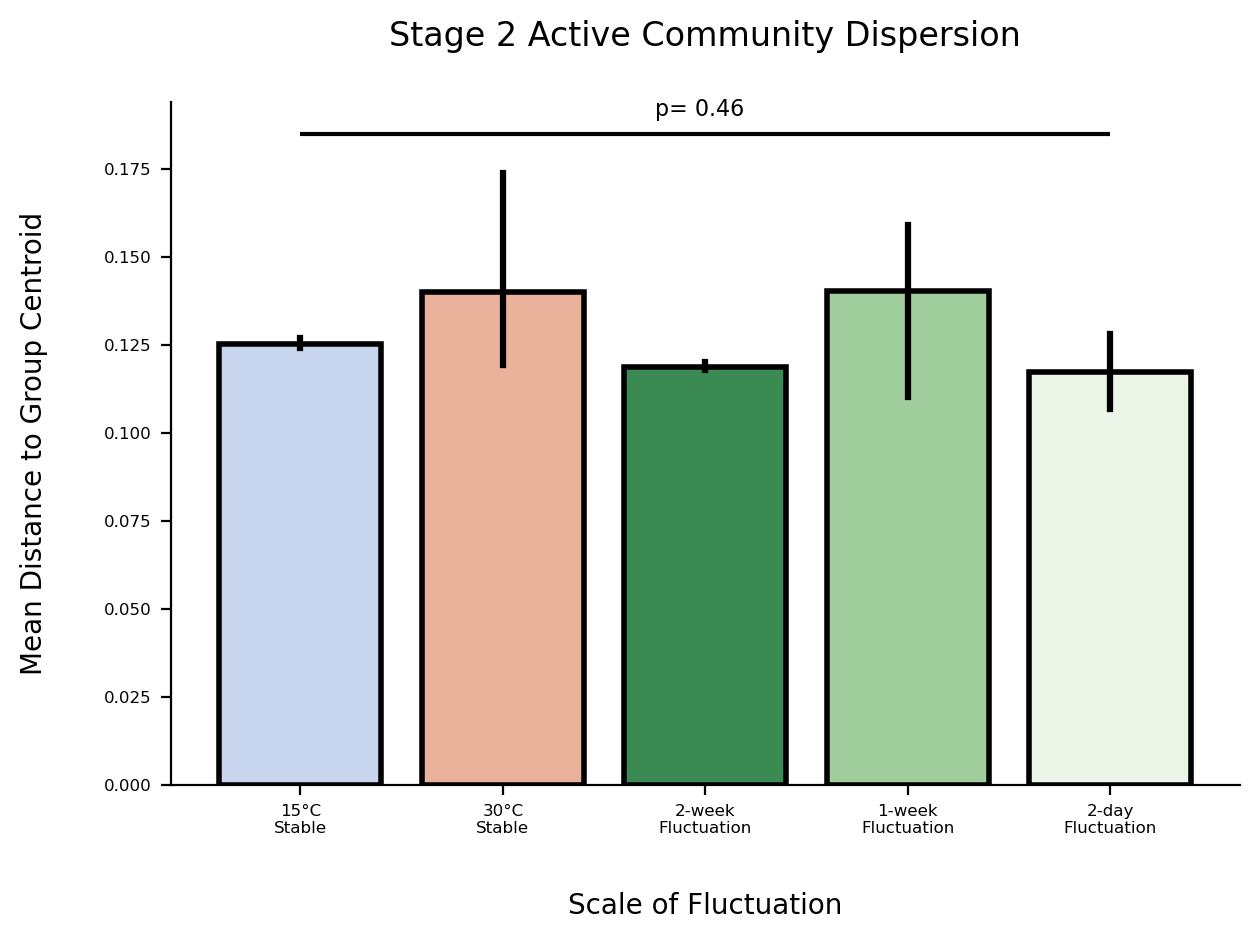

In [20]:

# Import data
plot_data = pd.read_csv("../Datasets/Diversity/Beta/StageTwoActive_dispersion.csv")
plot_data.columns= ['Sample', 'Distance']
plot_data['Sample'] = [sample[1:] for sample in plot_data['Sample']]    # Remove 'X' from sample numbers
plot_data = pd.merge(left= plot_data, right= sample_data, how= 'left', on= 'Sample')


# Create colour palette
colours = ['#c0d4f5', '#f7ac8e','#2f974e', '#98d594', '#e9f7e5']
labels = {'lowT':'15°C\nStable','highT':'30°C\nStable','2Weeks':'2-week\nFluctuation','1Week':'1-week\nFluctuation','2Days':'2-day\nFluctuation'}

plot_data['Scale of fluctuation'] = plot_data['Scale of fluctuation'].map(labels)

# Plot
plt.figure(dpi= 200)
plot = sns.barplot(data= plot_data, x= 'Scale of fluctuation', y= 'Distance', order= labels.values(), palette= colours, linewidth= 2, edgecolor= 'black',
           err_kws= {'color': 'black'}, estimator= 'mean')

# Add statistics annotation
p_value = np.round(ro.r['p_value'][0],2)
plt.hlines(xmin= 0,xmax= 4, y= 0.185, color= 'Black')
plt.text(x= 1.75, y= 0.19, s= f"p= {p_value}", fontsize= 8)

# Tidy up
plt.xticks(rotation= 0, fontsize= 6)
plt.yticks(fontsize= 6)
plt.xlabel('Scale of Fluctuation',fontsize= 10, labelpad= 20)
plt.ylabel('Mean Distance to Group Centroid',fontsize= 10, labelpad= 20)
plt.title("Stage 2 Active Community Dispersion", pad= 20)
sns.despine()
plt.tight_layout()

# Save to file
plt.savefig("../Figures/Diversity/Beta/StageTwoActive_dispersion.png")

# Reference

https://rdocumentation.org/packages/vegan/versions/2.6-4/topics/adonis  
https://www.rdocumentation.org/packages/ape/versions/5.8/topics/pcoa